In [2]:
import pandas as pd
import numpy as np
import formula_descriptors

# Load Cytotoxicity data

In [3]:
dataset = pd.read_csv("data/kim_model_data_for_ml.csv")
dataset

,Concentration,Compound,Cytotoxicity
0,0.1,PFHxS,3.100000e-18
1,5.0,PFHxS,2.940000e-07
2,10.0,PFHxS,2.270000e-05
3,20.0,PFHxS,1.494304e-03
4,40.0,PFHxS,7.297822e-02
...,...,...,...
721,160.0,Mix48,5.920338e+00
722,320.0,Mix48,8.215506e+01
723,640.0,Mix48,9.973611e+01
724,1280.0,Mix48,9.974000e+01


### Normalize

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Clip the upper to be 100
dataset['Cytotoxicity'] = dataset['Cytotoxicity'].clip(upper=100)

# Initialize the MinMaxScaler to scale values to the range [0, 1]
scaler = MinMaxScaler()

# Fit the scaler on the target variable and transform it
dataset["Cytotoxicity"] = scaler.fit_transform(dataset["Cytotoxicity"].values.reshape(-1, 1))

dataset["Concentration"] = dataset["Concentration"]/1000000

dataset

,Concentration,Compound,Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20
1,5.000000e-06,PFHxS,2.940000e-09
2,1.000000e-05,PFHxS,2.270000e-07
3,2.000000e-05,PFHxS,1.494304e-05
4,4.000000e-05,PFHxS,7.297822e-04
...,...,...,...
721,1.600000e-04,Mix48,5.920338e-02
722,3.200000e-04,Mix48,8.215506e-01
723,6.400000e-04,Mix48,9.973611e-01
724,1.280000e-03,Mix48,9.974000e-01


# Generate training data (single ingredient only)

In [5]:
train = pd.read_csv("data/KIM_pubchem_hepg2_chemberta_embeddings_PRETRAINED.csv", index_col=0)
train = train[["compound"]+[ "emb_{}".format(i) for i in range(0,384) ]]
train.set_index('compound', inplace=True)
train

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
compound,,,,,,,,,,,,,,,,,,,,,
"2,4-DCP",-0.203974,-0.410538,0.306956,0.261530,0.440526,0.314276,-0.251421,-0.076796,0.152720,0.323031,...,-0.115475,0.127195,0.157137,-0.160100,-0.049632,0.595075,-0.029975,0.042955,-0.569240,-0.557910
"2,5-DCP",-0.222304,-0.347414,0.238010,0.251454,0.369821,0.446243,-0.151686,0.009216,0.342188,0.114500,...,-0.028618,0.159067,0.203147,-0.113905,-0.079814,0.527337,0.074123,-0.032342,-0.667895,-0.382042
pPB,-0.166339,0.047658,0.244787,-0.182707,0.095819,0.728261,0.022458,0.221837,-0.361281,0.173565,...,0.138646,-0.386101,-0.030211,0.488119,-0.224447,-0.616820,-0.109350,-0.045636,-0.160471,-0.034435
bPB,-0.203045,-0.127237,-0.011560,-0.080164,-0.233172,0.688245,0.001760,0.093097,-0.393314,0.308487,...,0.019093,-0.565440,0.137755,0.286777,-0.156017,-0.488289,-0.222201,0.009742,-0.032303,-0.061349
BP-3,-0.314926,-0.344020,-0.183164,0.108446,0.191268,0.047018,-0.307485,-0.041466,0.026257,0.338129,...,-0.032672,0.232659,0.011698,-0.047628,-0.155434,-0.363887,0.114597,-0.153231,0.034144,-0.386518
TCS,-0.073396,-0.237268,0.147846,0.157346,0.204466,0.482117,0.058143,0.057820,0.317711,0.119867,...,-0.060007,0.258674,0.083459,-0.061057,0.039714,0.702439,-0.045842,0.020202,-0.638991,-0.429899
Pb,0.194862,-0.140300,0.022887,0.027048,0.318357,0.206641,-0.036324,0.355743,0.437495,-0.124737,...,0.075994,0.203077,0.221284,-0.851164,0.371775,0.282653,-0.305988,-0.297511,-0.530321,-0.168582
Cu,0.325776,0.138216,0.043289,-0.388204,-0.249000,-0.223992,0.175353,0.066848,0.058558,0.267022,...,-0.043703,0.001012,0.208985,-0.114274,-0.248643,0.157556,0.396387,-0.171929,0.518429,-0.275567
Se,0.120077,0.232969,-0.259653,-0.300351,-0.592487,-0.110936,0.104467,0.059162,0.265819,0.183641,...,-0.092952,-0.144116,0.248996,0.047398,-0.253421,0.066058,0.383158,-0.124992,0.379578,-0.339573


In [6]:
training_set = dataset.merge(train, left_on='Compound', right_index=True)
training_set

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,1.000000e-07,PFHxS,3.100000e-20,0.285464,-0.324682,-0.010733,0.467914,0.25871,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
1,5.000000e-06,PFHxS,2.940000e-09,0.285464,-0.324682,-0.010733,0.467914,0.25871,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
2,1.000000e-05,PFHxS,2.270000e-07,0.285464,-0.324682,-0.010733,0.467914,0.25871,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
3,2.000000e-05,PFHxS,1.494304e-05,0.285464,-0.324682,-0.010733,0.467914,0.25871,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
4,4.000000e-05,PFHxS,7.297822e-04,0.285464,-0.324682,-0.010733,0.467914,0.25871,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,1.600000e-04,TBOEP,1.507378e-01,-0.471680,0.051548,-0.044535,0.095480,-0.06723,0.219504,0.021293,...,-0.003526,-0.477803,-0.167990,0.077640,-0.075365,-0.495041,0.160661,0.208743,0.068113,0.256148
304,3.200000e-04,TBOEP,5.331098e-01,-0.471680,0.051548,-0.044535,0.095480,-0.06723,0.219504,0.021293,...,-0.003526,-0.477803,-0.167990,0.077640,-0.075365,-0.495041,0.160661,0.208743,0.068113,0.256148
305,6.400000e-04,TBOEP,9.720049e-01,-0.471680,0.051548,-0.044535,0.095480,-0.06723,0.219504,0.021293,...,-0.003526,-0.477803,-0.167990,0.077640,-0.075365,-0.495041,0.160661,0.208743,0.068113,0.256148
306,1.280000e-03,TBOEP,9.918885e-01,-0.471680,0.051548,-0.044535,0.095480,-0.06723,0.219504,0.021293,...,-0.003526,-0.477803,-0.167990,0.077640,-0.075365,-0.495041,0.160661,0.208743,0.068113,0.256148


In [7]:
#X_train = np.array(training_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_train = np.array(training_set.Cytotoxicity.values)

# Now generate test data

### load mixture mapping data

In [8]:
mixture_info = pd.read_json('data/mixture_data_for_mapping.json', orient='index')
mixture_info

,Compound Names,Smiles,Mole Fractions,Molecular Weights (g/mol)
Mix1,"[PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB, Hg, Cu, Se...",[C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(C(C(F)(F)F...,"[7.29, 20.36, 18.92, 16.71, 11.88, 0.72, 0.33,...","[438.2, 163.0, 20.74, 180.2, 194.23, 251.1, 24..."
Mix2,"[PFNA, PFOA, BP-3, TCS, pPB, Hg, Cd, Sb]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.3, 17.56, 26.52, 0.59, 31.49, 1.35, 0.1, 8...","[464.08, 414.07, 228.1, 289.54, 180.2, 251.1, ..."
Mix3,"[BP-3, bPB, Co, Cu, Pb, Cd, Se, Zn, Sb, Ni]","[COc1ccc(c(c1)O)C(=O)c1ccccc1, CCCCOC(=O)c1ccc...","[14.13, 11.92, 16.96, 0.33, 23.63, 0.05, 0.26,...","[228.1, 194.23, 129.84, 249.7, 278.0, 183.3, 1..."
Mix4,"[TEHP, TDCPP, EHDPHP, TPhP, TnBP, TCPP, TBOEP]","[CCCCC(COP(=O)(OCC(CCCC)CC)OCC(CCCC)CC)CC, ClC...","[26.29, 14.07, 8.58, 5.27, 16.56, 17.39, 11.85]","[434.63, 430.9, 362.4, 362.4, 326.3, 398.5, 39..."
Mix5,"[2,4-DCP, 2,5-DCP, pPB, bPB, BP-3, TCS, TnBP, ...","[Clc1ccc(c(c1)Cl)O, Clc1ccc(c(c1)O)Cl, CCCOC(=...","[19.06, 17.71, 15.65, 11.12, 13.18, 0.29, 9.71...","[163.0, 163.0, 180.2, 194.23, 228.1, 289.54, 3..."
Mix6,"[PFNA, PFOA, PFHxS, EHDPHP, TBOEP, TDCPP, TEHP...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[14.45, 17.74, 13.87, 10.22, 14.13, 16.77, 6.5...","[464.08, 414.07, 438.2, None, 398.5, 430.9, 43..."
Mix7,"[Co, Cu, Pb, Cd, Se, Zn, Sb, Hg, Ni]","[Cl[Co]Cl, [O-]S(=O)(=O)[O-], Cl[Pb]Cl, Cl[Cd]...","[22.72, 0.45, 31.65, 0.07, 0.35000000000000003...","[129.84, 249.7, 278.0, 183.3, 172.95, 287.6, 2..."
Mix8,"[Pb, Cd, Zn, Hg, TBOEP, TDCPP, TEHP]","[Cl[Pb]Cl, Cl[Cd]Cl, [O-]S(=O)(=O)[O-], C[Hg]C...","[39.88, 0.09, 25.5, 1.21, 12.58, 14.93, 5.8100...","[278.0, 183.3, 287.6, 251.1, 398.5, 430.9, 434..."
Mix9,"[PFNA, PFOA, PFHxS, 2,4-DCP, 2,5-DCP, pPB, bPB...",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[7.13, 8.76, 6.85, 19.13, 17.77, 15.7, 11.16, ...","[464.08, 414.07, 438.2, 163.0, 163.0, 180.2, 1..."
Mix10,"[PFNA, PFOA, PFHxS, Co, Cu, Se, Sb, Ni]",[OC(=O)C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(...,"[12.82, 15.74, 12.31, 28.53, 0.56, 0.44, 7.25,...","[464.08, 414.07, 438.2, 129.84, 249.7, 172.95,..."


In [9]:
mixture_info = mixture_info.drop(index='Mix15')
mixture_info = mixture_info.drop(index='Mix3')

### Calculate formula molecular descriptors

In [10]:
mix_emb_df = formula_descriptors.formulate_descriptors(mixture_info, train)
mix_emb_df

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
Mix1,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,0.123604,0.086929,0.087190,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
Mix2,0.026950,-0.116171,0.148827,0.039009,0.053822,0.273356,-0.171865,0.203043,0.005334,0.147733,...,-0.138818,0.007599,0.012220,-0.028799,-0.045322,-0.299590,0.070820,-0.051373,0.004209,-0.228894
Mix4,-0.192375,-0.091798,-0.130777,0.023064,0.030020,0.218670,-0.039812,0.135031,-0.070068,0.085449,...,0.040145,-0.329549,-0.028164,0.013962,-0.154211,-0.480029,0.040178,0.165306,0.169689,-0.073339
Mix5,-0.205869,-0.212031,0.080402,0.070933,0.146537,0.385373,-0.130236,0.044681,-0.026311,0.200248,...,-0.006947,-0.099698,0.078527,0.057827,-0.116847,-0.090852,-0.012111,0.013320,-0.227467,-0.275674
Mix6,0.108251,-0.134556,0.070575,0.166786,0.027881,0.087015,-0.061786,0.220278,0.052961,0.009554,...,-0.165336,-0.115390,-0.027550,-0.133525,-0.061004,-0.345737,0.078998,0.071289,0.151607,-0.184837
Mix7,0.204362,-0.091753,0.003351,-0.095210,0.064372,0.089473,-0.034283,0.172780,0.181255,0.040567,...,0.141025,-0.013583,0.168957,-0.271062,0.165243,0.156637,-0.061972,-0.180537,-0.179984,-0.096588
Mix8,0.082920,-0.044106,-0.000749,-0.085902,0.046027,0.075725,0.002220,0.197745,0.127903,0.059067,...,0.047233,-0.020296,0.124248,-0.300794,0.009314,-0.037464,-0.018938,-0.129953,-0.047764,-0.202706
Mix9,-0.084504,-0.237345,0.185620,0.138101,0.166037,0.333923,-0.137934,0.095418,0.045833,0.165900,...,-0.094033,-0.016277,0.072833,-0.017755,-0.096504,-0.038946,0.005377,-0.033198,-0.221811,-0.310304
Mix10,0.252933,-0.178818,0.076926,0.093379,0.032676,0.073516,-0.114391,0.185728,0.158005,-0.027945,...,-0.033440,-0.068220,0.053805,-0.150601,0.124345,-0.035569,-0.001504,-0.064385,-0.069342,-0.086704
Mix11,0.099117,-0.143261,0.095729,0.043304,0.074004,0.176087,-0.043803,0.155223,0.120632,0.044137,...,-0.031042,0.004683,0.137752,-0.220752,-0.011103,0.026036,-0.021071,-0.107390,-0.155833,-0.281940


In [11]:
testing_set = dataset.merge(mix_emb_df, left_on='Compound', right_index=True)
testing_set

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
99,1.000000e-07,Mix1,0.000102,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
100,5.000000e-06,Mix1,0.000137,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
101,1.000000e-05,Mix1,0.000182,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
102,2.000000e-05,Mix1,0.000314,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
103,4.000000e-05,Mix1,0.000841,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,1.600000e-04,Mix48,0.059203,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
722,3.200000e-04,Mix48,0.821551,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
723,6.400000e-04,Mix48,0.997361,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
724,1.280000e-03,Mix48,0.997400,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621


In [12]:
#X_test = np.array(testing_set.drop(columns=["Compound", "Cytotoxicity"]))
#y_test = np.array(testing_set.Cytotoxicity.values)

# Make train/test splits at the sample level

In [13]:
altogether = pd.concat([training_set, testing_set], ignore_index=True)
altogether

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,1.000000e-07,PFHxS,3.100000e-20,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
1,5.000000e-06,PFHxS,2.940000e-09,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
2,1.000000e-05,PFHxS,2.270000e-07,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
3,2.000000e-05,PFHxS,1.494304e-05,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
4,4.000000e-05,PFHxS,7.297822e-04,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.128190,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,1.600000e-04,Mix48,5.920338e-02,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
689,3.200000e-04,Mix48,8.215506e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
690,6.400000e-04,Mix48,9.973611e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621
691,1.280000e-03,Mix48,9.974000e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.031726,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621


In [14]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(altogether, test_size=0.2, random_state=42)

In [15]:
train

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
110,1.000000e-07,PFNA,9.000000e-87,0.402299,-0.141339,0.437722,0.196876,-0.088933,0.110381,-0.190598,...,-0.477831,0.284086,0.047235,-0.423253,0.174342,-0.002027,0.208488,0.000713,0.218582,-0.334103
82,8.000000e-05,Se,4.758596e-01,0.120077,0.232969,-0.259653,-0.300351,-0.592487,-0.110936,0.104467,...,-0.092952,-0.144116,0.248996,0.047398,-0.253421,0.066058,0.383158,-0.124992,0.379578,-0.339573
51,3.200000e-04,bPB,4.085018e-01,-0.203045,-0.127237,-0.011560,-0.080164,-0.233172,0.688245,0.001760,...,0.019093,-0.565440,0.137755,0.286777,-0.156017,-0.488289,-0.222201,0.009742,-0.032303,-0.061349
218,1.280000e-03,TCPP,9.797999e-01,-0.052683,-0.274522,-0.264440,-0.063977,0.026483,0.087111,-0.140832,...,-0.073808,-0.172707,-0.000014,0.092380,-0.249934,-0.598218,-0.149074,0.122491,0.040879,-0.535354
622,1.600000e-04,Mix41,3.147748e-02,0.079056,0.018654,-0.003887,0.017906,-0.110587,0.061761,-0.055286,...,-0.046681,-0.201457,0.065355,0.004985,-0.144299,-0.316833,0.062373,-0.032559,0.215023,-0.135928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.000000e-05,Cu,5.663040e-01,0.325776,0.138216,0.043289,-0.388204,-0.249000,-0.223992,0.175353,...,-0.043703,0.001012,0.208985,-0.114274,-0.248643,0.157556,0.396387,-0.171929,0.518429,-0.275567
106,3.200000e-04,TCS,1.000000e+00,-0.073396,-0.237268,0.147846,0.157346,0.204466,0.482117,0.058143,...,-0.060007,0.258674,0.083459,-0.061057,0.039714,0.702439,-0.045842,0.020202,-0.638991,-0.429899
270,1.600000e-04,Mix1,3.910159e-02,-0.066117,-0.215415,0.151418,0.097994,0.240896,0.378525,-0.072692,...,0.007636,-0.052475,0.120547,-0.139468,-0.024745,0.075884,-0.115184,-0.086009,-0.397430,-0.265433
435,1.600000e-04,Mix20,1.230221e-05,0.044313,0.002028,0.055638,-0.041501,-0.066493,0.201504,-0.023574,...,0.017548,-0.218595,0.068862,0.135968,-0.174059,-0.380879,-0.001505,-0.053397,0.149642,-0.163164


In [16]:
test

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
381,3.200000e-04,Mix13,0.578401,-0.113177,-0.066297,-0.127985,0.122024,0.038658,0.158712,-0.095079,...,0.014247,-0.249561,0.021776,0.035240,-0.134771,-0.448821,-0.002731,-0.012960,0.124034,-0.035739
665,8.000000e-05,Mix46,0.012697,0.144996,-0.138815,-0.088083,-0.058224,0.015181,0.035156,-0.029201,...,0.071322,-0.161757,0.070266,0.021115,-0.081081,-0.185673,-0.007184,-0.053803,0.036550,-0.180804
257,4.000000e-05,TBOEP,0.041896,-0.471680,0.051548,-0.044535,0.095480,-0.067230,0.219504,0.021293,...,-0.003526,-0.477803,-0.167990,0.077640,-0.075365,-0.495041,0.160661,0.208743,0.068113,0.256148
338,6.400000e-04,Mix8,0.964789,0.082920,-0.044106,-0.000749,-0.085902,0.046027,0.075725,0.002220,...,0.047233,-0.020296,0.124248,-0.300794,0.009314,-0.037464,-0.018938,-0.129953,-0.047764,-0.202706
319,1.000000e-07,Mix7,0.021693,0.204362,-0.091753,0.003351,-0.095210,0.064372,0.089473,-0.034283,...,0.141025,-0.013583,0.168957,-0.271062,0.165243,0.156637,-0.061972,-0.180537,-0.179984,-0.096588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8.000000e-05,Mix31,0.000224,0.090304,-0.160989,-0.066569,0.054853,0.068593,0.091050,-0.052911,...,0.125558,-0.245432,0.019268,-0.021358,0.070567,-0.111768,-0.050395,-0.047485,-0.142505,0.035666
24,1.000000e-05,"2,5-DCP",0.000034,-0.222304,-0.347414,0.238010,0.251454,0.369821,0.446243,-0.151686,...,-0.028618,0.159067,0.203147,-0.113905,-0.079814,0.527337,0.074123,-0.032342,-0.667895,-0.382042
158,4.000000e-05,Co,0.000090,0.141828,-0.536059,-0.010163,-0.187720,0.234311,0.088731,-0.021918,...,0.321267,0.014754,-0.025883,-0.175215,0.467200,0.567685,0.063454,-0.043958,-0.648628,0.140360
521,4.000000e-05,Mix32,0.001858,-0.054156,-0.192014,-0.134812,-0.046898,0.022168,0.131579,-0.076069,...,0.049412,-0.201491,-0.028626,-0.045933,0.027442,-0.179739,0.046976,0.088937,-0.100050,-0.082146


In [17]:
X_train = np.array(train.drop(columns=["Compound", "Cytotoxicity"]))
y_train = np.array(train.Cytotoxicity.values)

In [18]:
X_test = np.array(test.drop(columns=["Compound", "Cytotoxicity"]))
y_test = np.array(test.Cytotoxicity.values)

# Grid Search

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [20]:
import json

param_grid = {
    'n_estimators': [100, 200, 300, 400],  # Number of trees
    'max_depth': [None, 10, 20, 30, 40],  # Tree depth
#    'min_samples_split': [2, 4, 6, 8, 10],  # Minimum number of samples to split
#    'min_samples_leaf': [1, 2, 4, 6, 8],  # Minimum number of samples at a leaf
#    'max_features': ['sqrt', 'log2', None],  # Number of features to consider at every split
#    'bootstrap': [True, False],  # Bootstrap samples are used when building trees
    'criterion': ['squared_error', 'absolute_error'],  # Measure of the quality of a split
    'random_state':[42]
}

In [21]:
# Define the model
rf = RandomForestRegressor()

In [22]:
best_score = 0.0
best_params = None
model = None

# Gonna iterate and evaluate each combination of parameters
for params in ParameterGrid(param_grid):

    rf.set_params(**params)

    # Fit the model
    rf.fit(X_train, y_train)

    # Make predictions on the test set and evaluate
    y_pred = rf.predict(X_test)
    score = r2_score(y_test, y_pred)

    # Check if this is the best model so far and then store (I know this is elementary)
    if score > best_score:
        best_score = score
        best_params = params
        model = rf

In [27]:
print(f"Best Parameters: {best_params}")

Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'n_estimators': 100, 'random_state': 42}


In [28]:
best =  RandomForestRegressor(criterion='squared_error', max_depth=10, n_estimators=100, random_state=42)
model = best.fit(X_train, y_train)
model

RandomForestRegressor(max_depth=10, random_state=42)

# Load the model

In [30]:
#model = RandomForestRegressor()
#model.fit(X_train, y_train)

In [31]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
r2

0.9235300108690435

In [32]:
mean_absolute_error(y_test, y_pred)

0.04646608349322701

In [33]:
mean_squared_error(y_test, y_pred)

0.012030802552841429

In [34]:
np.sqrt(mean_squared_error(y_test, y_pred))

0.10968501516999224

In [35]:
len(y_test)

139

In [29]:
test

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
381,3.200000e-04,Mix13,0.578401,0.102747,-0.266440,0.152150,0.369918,0.230967,-0.131164,-0.212363,...,-0.029613,0.102673,0.021080,0.137984,-0.016958,-0.344078,-0.091938,-0.266008,-0.396436,-0.208137
665,8.000000e-05,Mix46,0.012697,0.309455,-0.265269,0.174328,0.233152,0.093782,-0.115547,-0.269209,...,-0.075476,0.057839,0.090501,0.103458,0.063381,-0.174923,-0.247868,-0.247801,-0.466643,-0.227633
257,4.000000e-05,TBOEP,0.041896,-0.194818,-0.116627,0.081457,0.452656,0.155732,-0.251266,-0.000327,...,-0.090644,-0.139753,-0.272811,0.168291,0.120954,-0.273340,0.158711,-0.080187,-0.489991,-0.102841
338,6.400000e-04,Mix8,0.964789,0.224677,-0.015432,0.122534,0.194670,0.117578,-0.178003,-0.176065,...,-0.065052,0.026230,0.020568,-0.254215,0.060207,-0.139871,-0.186237,-0.219681,-0.354721,-0.328354
319,1.000000e-07,Mix7,0.021693,0.357134,-0.068272,0.240897,0.125188,0.087895,-0.052353,-0.227838,...,0.013175,-0.025643,0.131356,-0.157356,0.054062,-0.076036,-0.276445,-0.238706,-0.441791,-0.143794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8.000000e-05,Mix31,0.000224,0.262895,-0.272852,0.280607,0.241319,0.112830,-0.020998,-0.260751,...,0.018254,-0.058459,0.092575,0.144372,0.088894,-0.156745,-0.207126,-0.224271,-0.579511,-0.038076
24,1.000000e-05,"2,5-DCP",0.000034,-0.142800,-0.564727,-0.069918,0.507382,0.439908,0.146263,-0.532931,...,-0.396367,0.060893,0.097783,0.170509,-0.183774,0.054095,-0.056161,-0.240935,-0.729859,-0.415152
158,4.000000e-05,Co,0.000090,0.380191,-0.511575,0.386153,0.033707,0.122612,0.207646,-0.364274,...,0.035511,-0.252531,0.206112,0.088652,0.197240,0.200361,-0.424512,-0.198841,-0.970060,0.259789
521,4.000000e-05,Mix32,0.001858,0.151792,-0.309653,0.120565,0.297346,0.144529,-0.078096,-0.300286,...,-0.142509,-0.009245,0.014416,0.043766,0.190759,-0.183829,-0.191856,-0.154970,-0.658302,-0.154689


In [30]:
mix_test = np.array(test.drop(columns=["Compound","Cytotoxicity"]))
mix_test_y = np.array(test["Cytotoxicity"].values)

# Train validation

In [36]:
train_predicted = model.predict(X_train)

In [37]:
r2_score(y_train, train_predicted)

0.9874427451408301

# Load File

In [29]:
import pickle

pkl_file = '80_20_level_model_pretrained.pkl'

with open(pkl_file, 'wb') as file:
    pickle.dump(model, file)

In [27]:
import pickle

with open("80_20_level_model_pretrained.pkl", 'rb') as f:
    model = pickle.load(f)

# Let's analyze some of this

In [38]:
features = np.array(altogether.drop(columns=["Compound", "Cytotoxicity"]))

In [39]:
features

array([[ 1.00000000e-07,  2.85464380e-01, -3.24681760e-01, ...,
        -1.58898470e-01,  2.86563150e-02, -3.44559670e-01],
       [ 5.00000000e-06,  2.85464380e-01, -3.24681760e-01, ...,
        -1.58898470e-01,  2.86563150e-02, -3.44559670e-01],
       [ 1.00000000e-05,  2.85464380e-01, -3.24681760e-01, ...,
        -1.58898470e-01,  2.86563150e-02, -3.44559670e-01],
       ...,
       [ 6.40000000e-04, -5.29641227e-02, -1.90769959e-01, ...,
        -8.86117265e-02, -4.17954817e-01, -1.49621260e-01],
       [ 1.28000000e-03, -5.29641227e-02, -1.90769959e-01, ...,
        -8.86117265e-02, -4.17954817e-01, -1.49621260e-01],
       [ 2.56000000e-03, -5.29641227e-02, -1.90769959e-01, ...,
        -8.86117265e-02, -4.17954817e-01, -1.49621260e-01]])

In [40]:
altogether["predicted_Cytotoxicity"] = model.predict(features)

In [41]:
test.Compound.unique()

array(['Mix13', 'Mix46', 'TBOEP', 'Mix8', 'Mix7', 'TCPP', 'Mix12', 'Zn',
       'Mix6', 'Ni', 'Mix25', 'Se', 'Mix18', 'Mix21', 'Mix48', 'Mix44',
       'Mix33', 'Mix34', 'Mix4', 'Mix42', 'EHDPHP', 'bPB', 'Mix23',
       'Mix19', 'Sb', 'Mix45', 'TCS', 'Mix11', 'TDCPP', 'Mix47', 'Cu',
       'Mix36', 'Mix38', 'Mix32', 'Mix2', 'Pb', 'PFHxS', 'Hg', 'Mix22',
       'Mix37', '2,5-DCP', 'TPhP', 'Mix30', 'Mix9', 'Mix39', 'PFNA',
       'Mix35', 'Mix41', 'PFOA', 'Mix5', 'BP-3', 'Co', 'Mix31', 'Mix14',
       'Mix1', 'pPB', 'Cd', 'TEHP', 'Mix20'], dtype=object)

In [42]:
altogether.Compound.unique()

array(['PFHxS', '2,4-DCP', '2,5-DCP', 'pPB', 'bPB', 'Hg', 'Cu', 'Se',
       'Pb', 'TCS', 'PFNA', 'PFOA', 'Sb', 'BP-3', 'Co', 'Ni', 'Zn', 'Cd',
       'TEHP', 'TCPP', 'TPhP', 'TDCPP', 'EHDPHP', 'TBOEP', 'Mix1', 'Mix2',
       'Mix4', 'Mix5', 'Mix6', 'Mix7', 'Mix8', 'Mix9', 'Mix11', 'Mix12',
       'Mix13', 'Mix14', 'Mix17', 'Mix18', 'Mix19', 'Mix20', 'Mix21',
       'Mix22', 'Mix23', 'Mix25', 'Mix28', 'Mix30', 'Mix31', 'Mix32',
       'Mix33', 'Mix34', 'Mix35', 'Mix36', 'Mix37', 'Mix38', 'Mix39',
       'Mix40', 'Mix41', 'Mix42', 'Mix44', 'Mix45', 'Mix46', 'Mix47',
       'Mix48'], dtype=object)

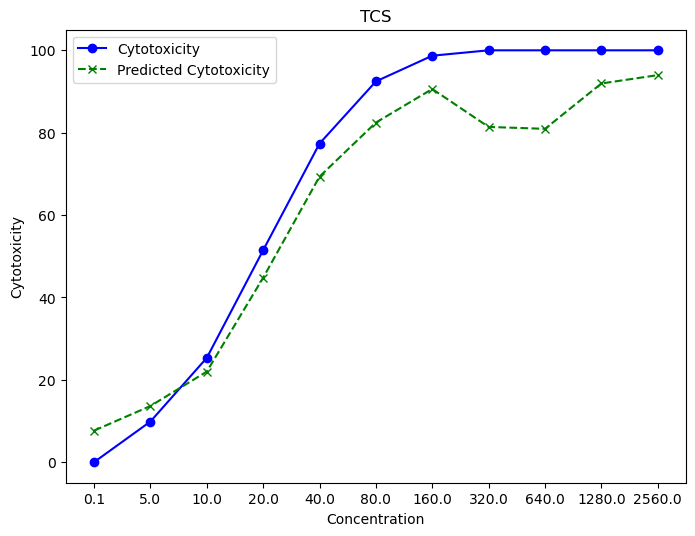

In [43]:
import matplotlib.pyplot as plt

compound_name = "TCS"

df = altogether[altogether["Compound"] == compound_name]
concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=100)
#plt.figure(figsize=(6,5))
plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
plt.title(compound_name)
plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
plt.legend()
#plt.savefig(f"/Users/shou626/Downloads/{compound_name}_newest.png", dpi=300, bbox_inches='tight')
plt.show()

In [44]:
altogether

,Concentration,Compound,Cytotoxicity,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,predicted_Cytotoxicity
0,1.000000e-07,PFHxS,3.100000e-20,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560,0.003941
1,5.000000e-06,PFHxS,2.940000e-09,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560,0.003941
2,1.000000e-05,PFHxS,2.270000e-07,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560,0.010490
3,2.000000e-05,PFHxS,1.494304e-05,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560,0.010490
4,4.000000e-05,PFHxS,7.297822e-04,0.285464,-0.324682,-0.010733,0.467914,0.258710,-0.288307,0.165986,...,-0.311215,-0.213678,-0.006683,-0.459122,-0.712698,-0.115647,-0.158898,0.028656,-0.344560,0.006175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,1.600000e-04,Mix48,5.920338e-02,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621,0.051195
689,3.200000e-04,Mix48,8.215506e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621,0.247039
690,6.400000e-04,Mix48,9.973611e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621,0.930741
691,1.280000e-03,Mix48,9.974000e-01,-0.052964,-0.190770,0.066223,0.110131,0.284177,0.303521,-0.045688,...,0.041134,0.145060,-0.375572,0.112127,0.184605,-0.077528,-0.088612,-0.417955,-0.149621,0.981853


Fold 1:
  R² Score: 0.8204
  MAE: 0.0909
  RMSE: 0.1822
------------------------------
Fold 2:
  R² Score: 0.9197
  MAE: 0.0652
  RMSE: 0.1222
------------------------------
Fold 3:
  R² Score: 0.9027
  MAE: 0.0705
  RMSE: 0.1372
------------------------------
Fold 4:
  R² Score: 0.8948
  MAE: 0.0554
  RMSE: 0.1247
------------------------------
Fold 5:
  R² Score: 0.9568
  MAE: 0.0447
  RMSE: 0.0925
------------------------------
Cross-Validation Results (5-fold):
Average R² Score: 0.8989 ± 0.0447
Average MAE: 0.0653 ± 0.0155
Average RMSE: 0.1317 ± 0.0292


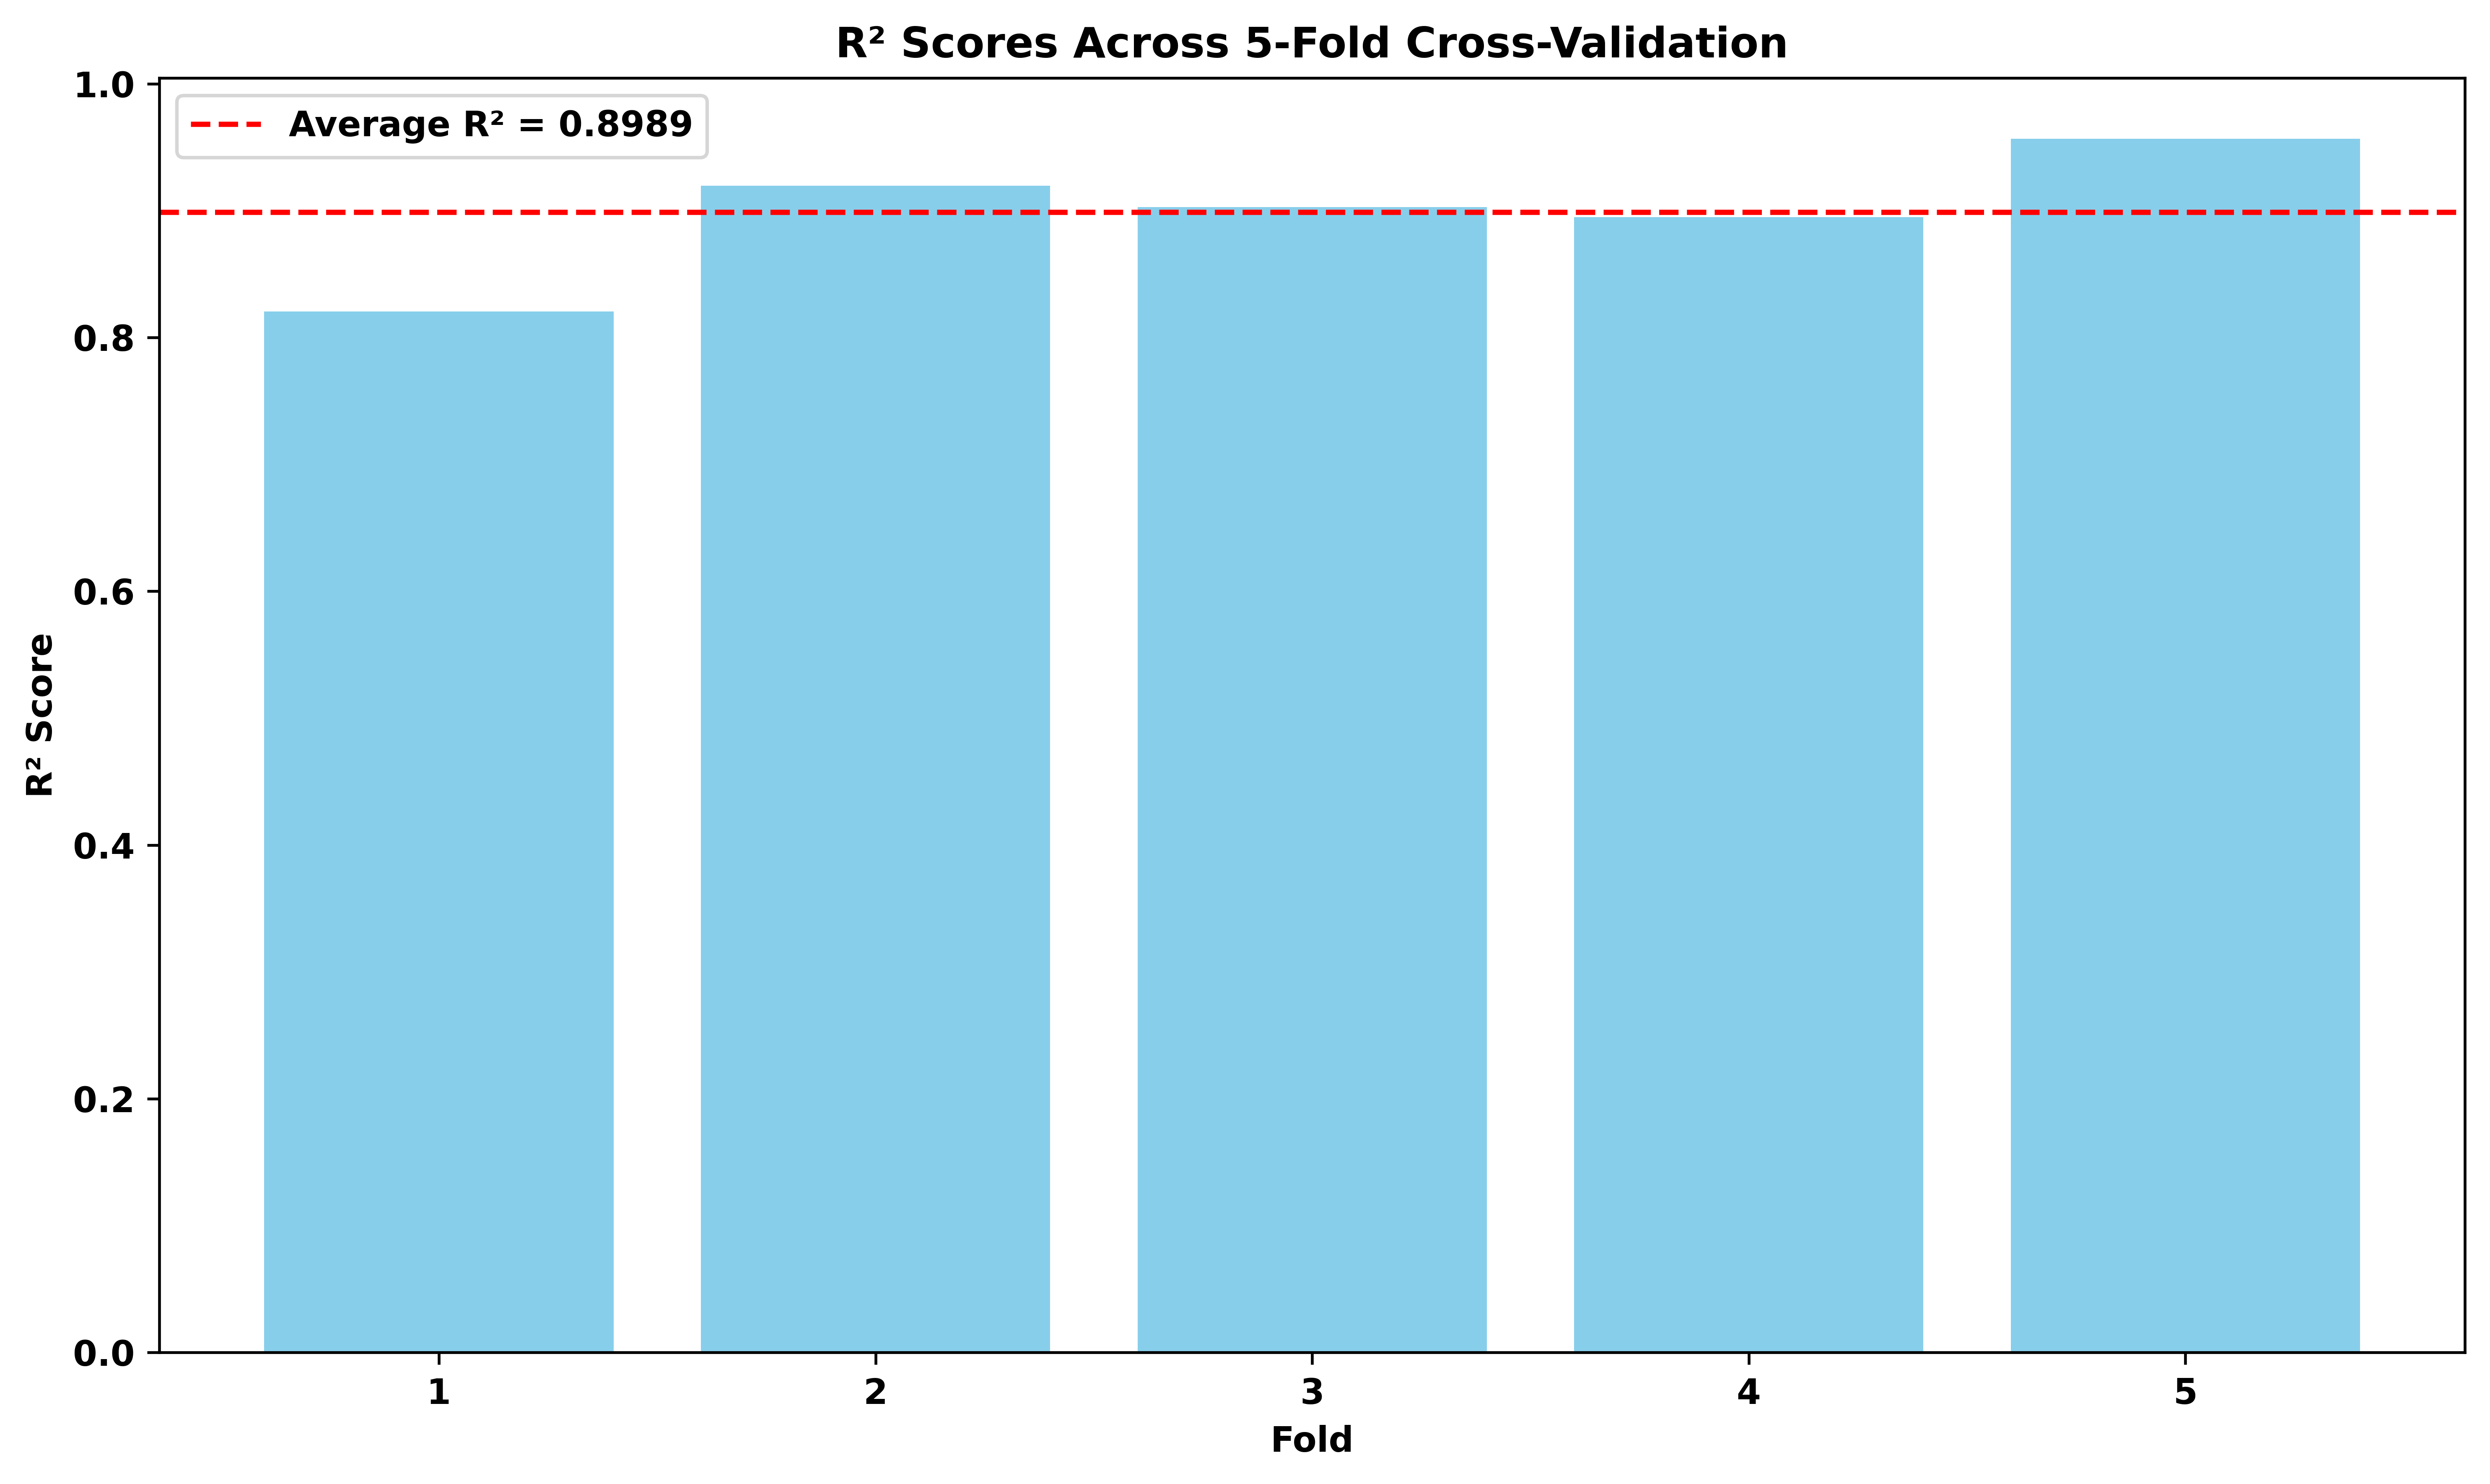

In [45]:
# 5-fold Cross-Validation on Training Set
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
 
# IMPORTANT: define the best model parameters from grid search
best_model = RandomForestRegressor(
    criterion='squared_error', 
    max_depth=10, 
    n_estimators=100, 
    random_state=42
)
 
# initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
# lists to store metrics for each fold
r2_scores = []
mae_scores = []
rmse_scores = []
 
# perform cross-validation
fold = 1
for train_index, val_index in kf.split(X_train):
 
    # split data
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
    best_model.fit(X_train_fold, y_train_fold)
    y_val_pred = best_model.predict(X_val_fold)
    # Calculate metrics
    r2 = r2_score(y_val_fold, y_val_pred)
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    # store metrics here
    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    # print the fold results
    print(f"Fold {fold}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print("-" * 30)
    fold += 1
 
# calculate and print average metrics
avg_r2 = np.mean(r2_scores)
avg_mae = np.mean(mae_scores)
avg_rmse = np.mean(rmse_scores)
std_r2 = np.std(r2_scores)
std_mae = np.std(mae_scores)
std_rmse = np.std(rmse_scores)
 
print("Cross-Validation Results (5-fold):")
print(f"Average R² Score: {avg_r2:.4f} ± {std_r2:.4f}")
print(f"Average MAE: {avg_mae:.4f} ± {std_mae:.4f}")
print(f"Average RMSE: {avg_rmse:.4f} ± {std_rmse:.4f}")
 
# plot the results for all model iterations
plt.figure(figsize=(10, 6), dpi=600)
plt.bar(range(1, 6), r2_scores, color='skyblue')
plt.axhline(y=avg_r2, color='red', linestyle='--', label=f'Average R² = {avg_r2:.4f}')
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('R² Score', fontweight='bold')
plt.title('R² Scores Across 5-Fold Cross-Validation', fontweight='bold')
plt.xticks(range(1, 6), fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.tight_layout()
plt.savefig('cv_r2_scores.png', dpi=600, bbox_inches='tight')
plt.show()

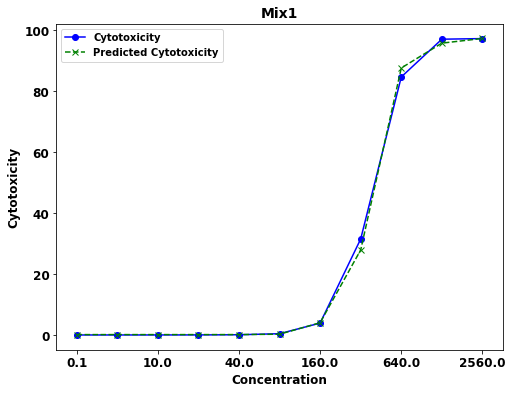

In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl
 
# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
 
# Example of improved plot function
def plot_compound(compound_name, dataframe):
    df = dataframe[dataframe["Compound"] == compound_name]
    # Plotting with improved settings
    fig, ax = plt.subplots(figsize=(8,6))
    # Plot data
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, 
             color='blue', marker='o', linestyle='-', label='Cytotoxicity')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, 
             color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')
    # Set title and labels with bold font
    plt.title(compound_name, fontweight='bold', fontsize=14)
    plt.xlabel('Concentration', fontweight='bold', fontsize=12)
    plt.ylabel('Cytotoxicity', fontweight='bold', fontsize=12)
    # Reduce x-axis ticks by showing fewer ticks
    # Get all x-tick positions
    all_xticks = [str(i*1000000) for i in df.Concentration]
    # Show only every nth tick (adjust n as needed)
    n = 2  # Show every 2nd tick
    plt.xticks(all_xticks[::n], all_xticks[::n], fontweight='bold')
    # Make y-ticks bold too
    plt.yticks(fontweight='bold')
    plt.legend(prop={'weight':'bold'})
    # Save with 600 dpi
    plt.savefig(f"{compound_name}_manuscript.png", dpi=600, bbox_inches='tight')
    plt.show()
 
# here is the function call for a specific compound
plot_compound(compound_name = "Mix1", dataframe = altogether)

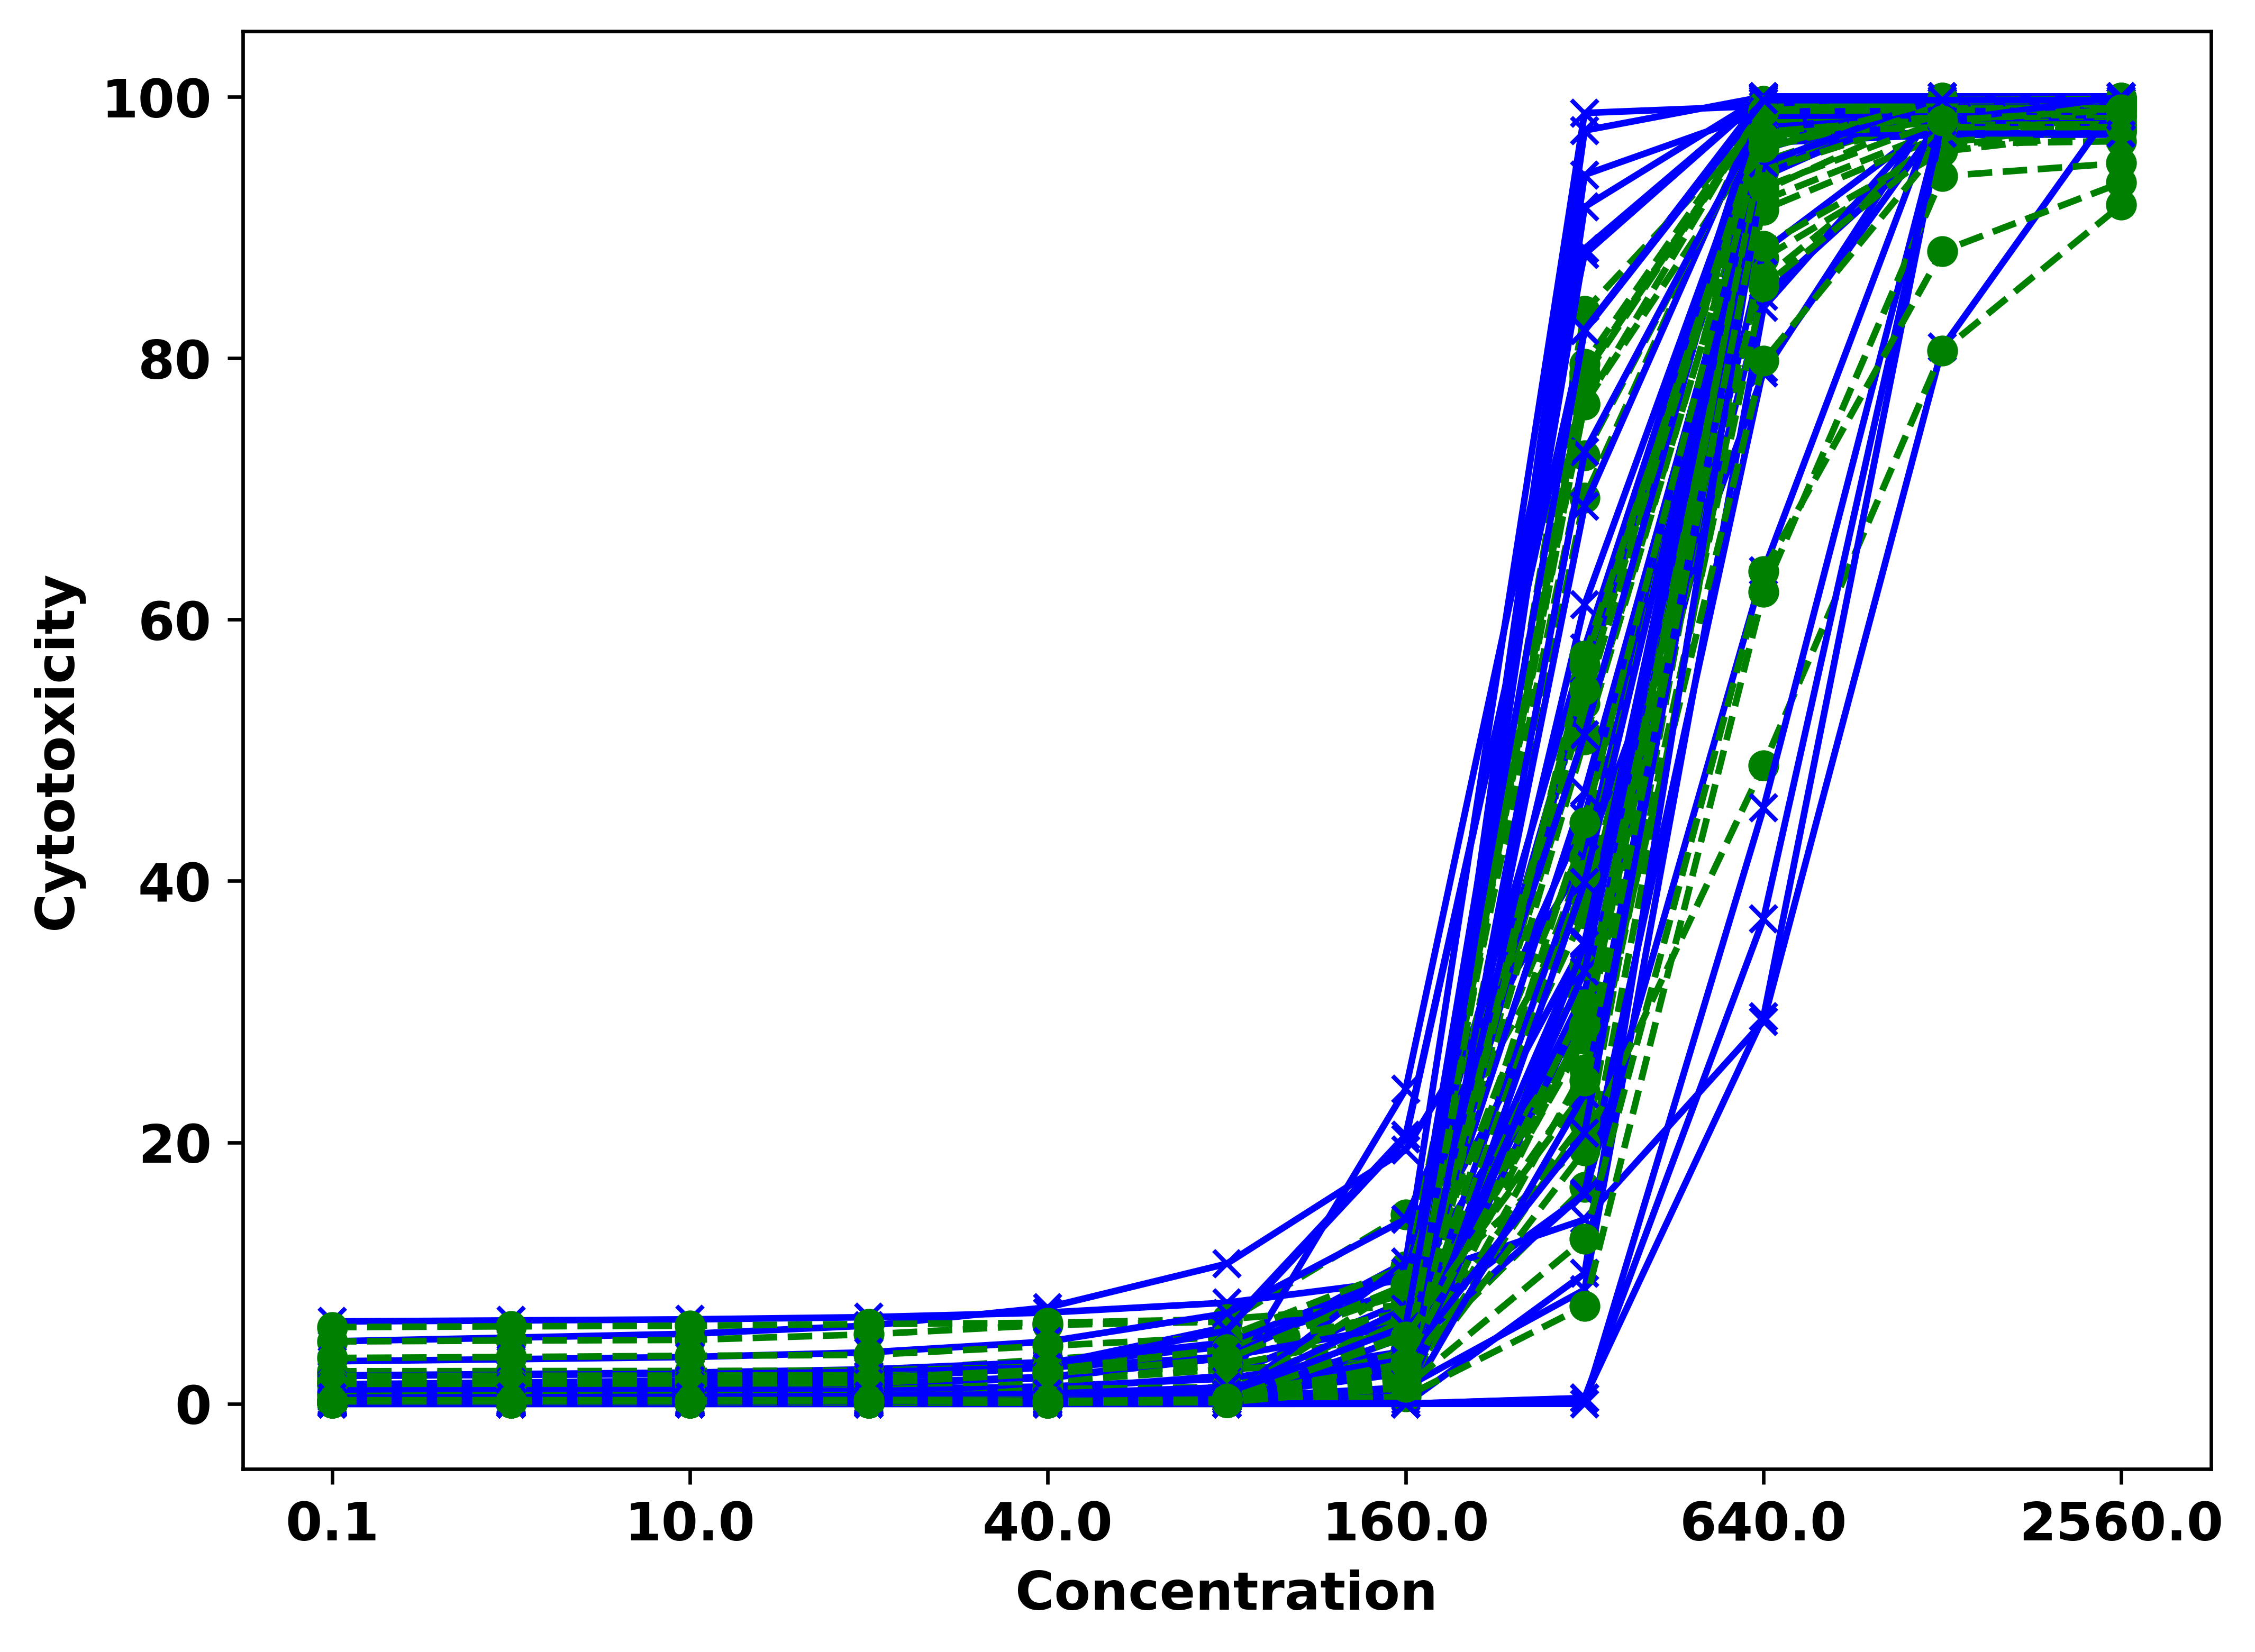

In [48]:
import matplotlib.pyplot as plt

mix_only = altogether[altogether['Compound'].str.contains('Mix')]

#compound_name = "Mix1"

#df = testing_set[testing_set["Compound"] == compound_name]
#concentration = df["Concentration"]

# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=600)
#plt.figure(figsize=(6,5))

for compound_name in mix_only.Compound.unique():
    
    df = mix_only[mix_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    
    
#plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
#plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
#plt.title(compound_name)
all_xticks = [str(i*1000000) for i in df.Concentration]
plt.xticks(all_xticks[::2], all_xticks[::2], fontweight='bold')

plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
#plt.legend()
plt.savefig("manu_figs/mixtures_only.png", dpi=600, bbox_inches='tight')
plt.show()

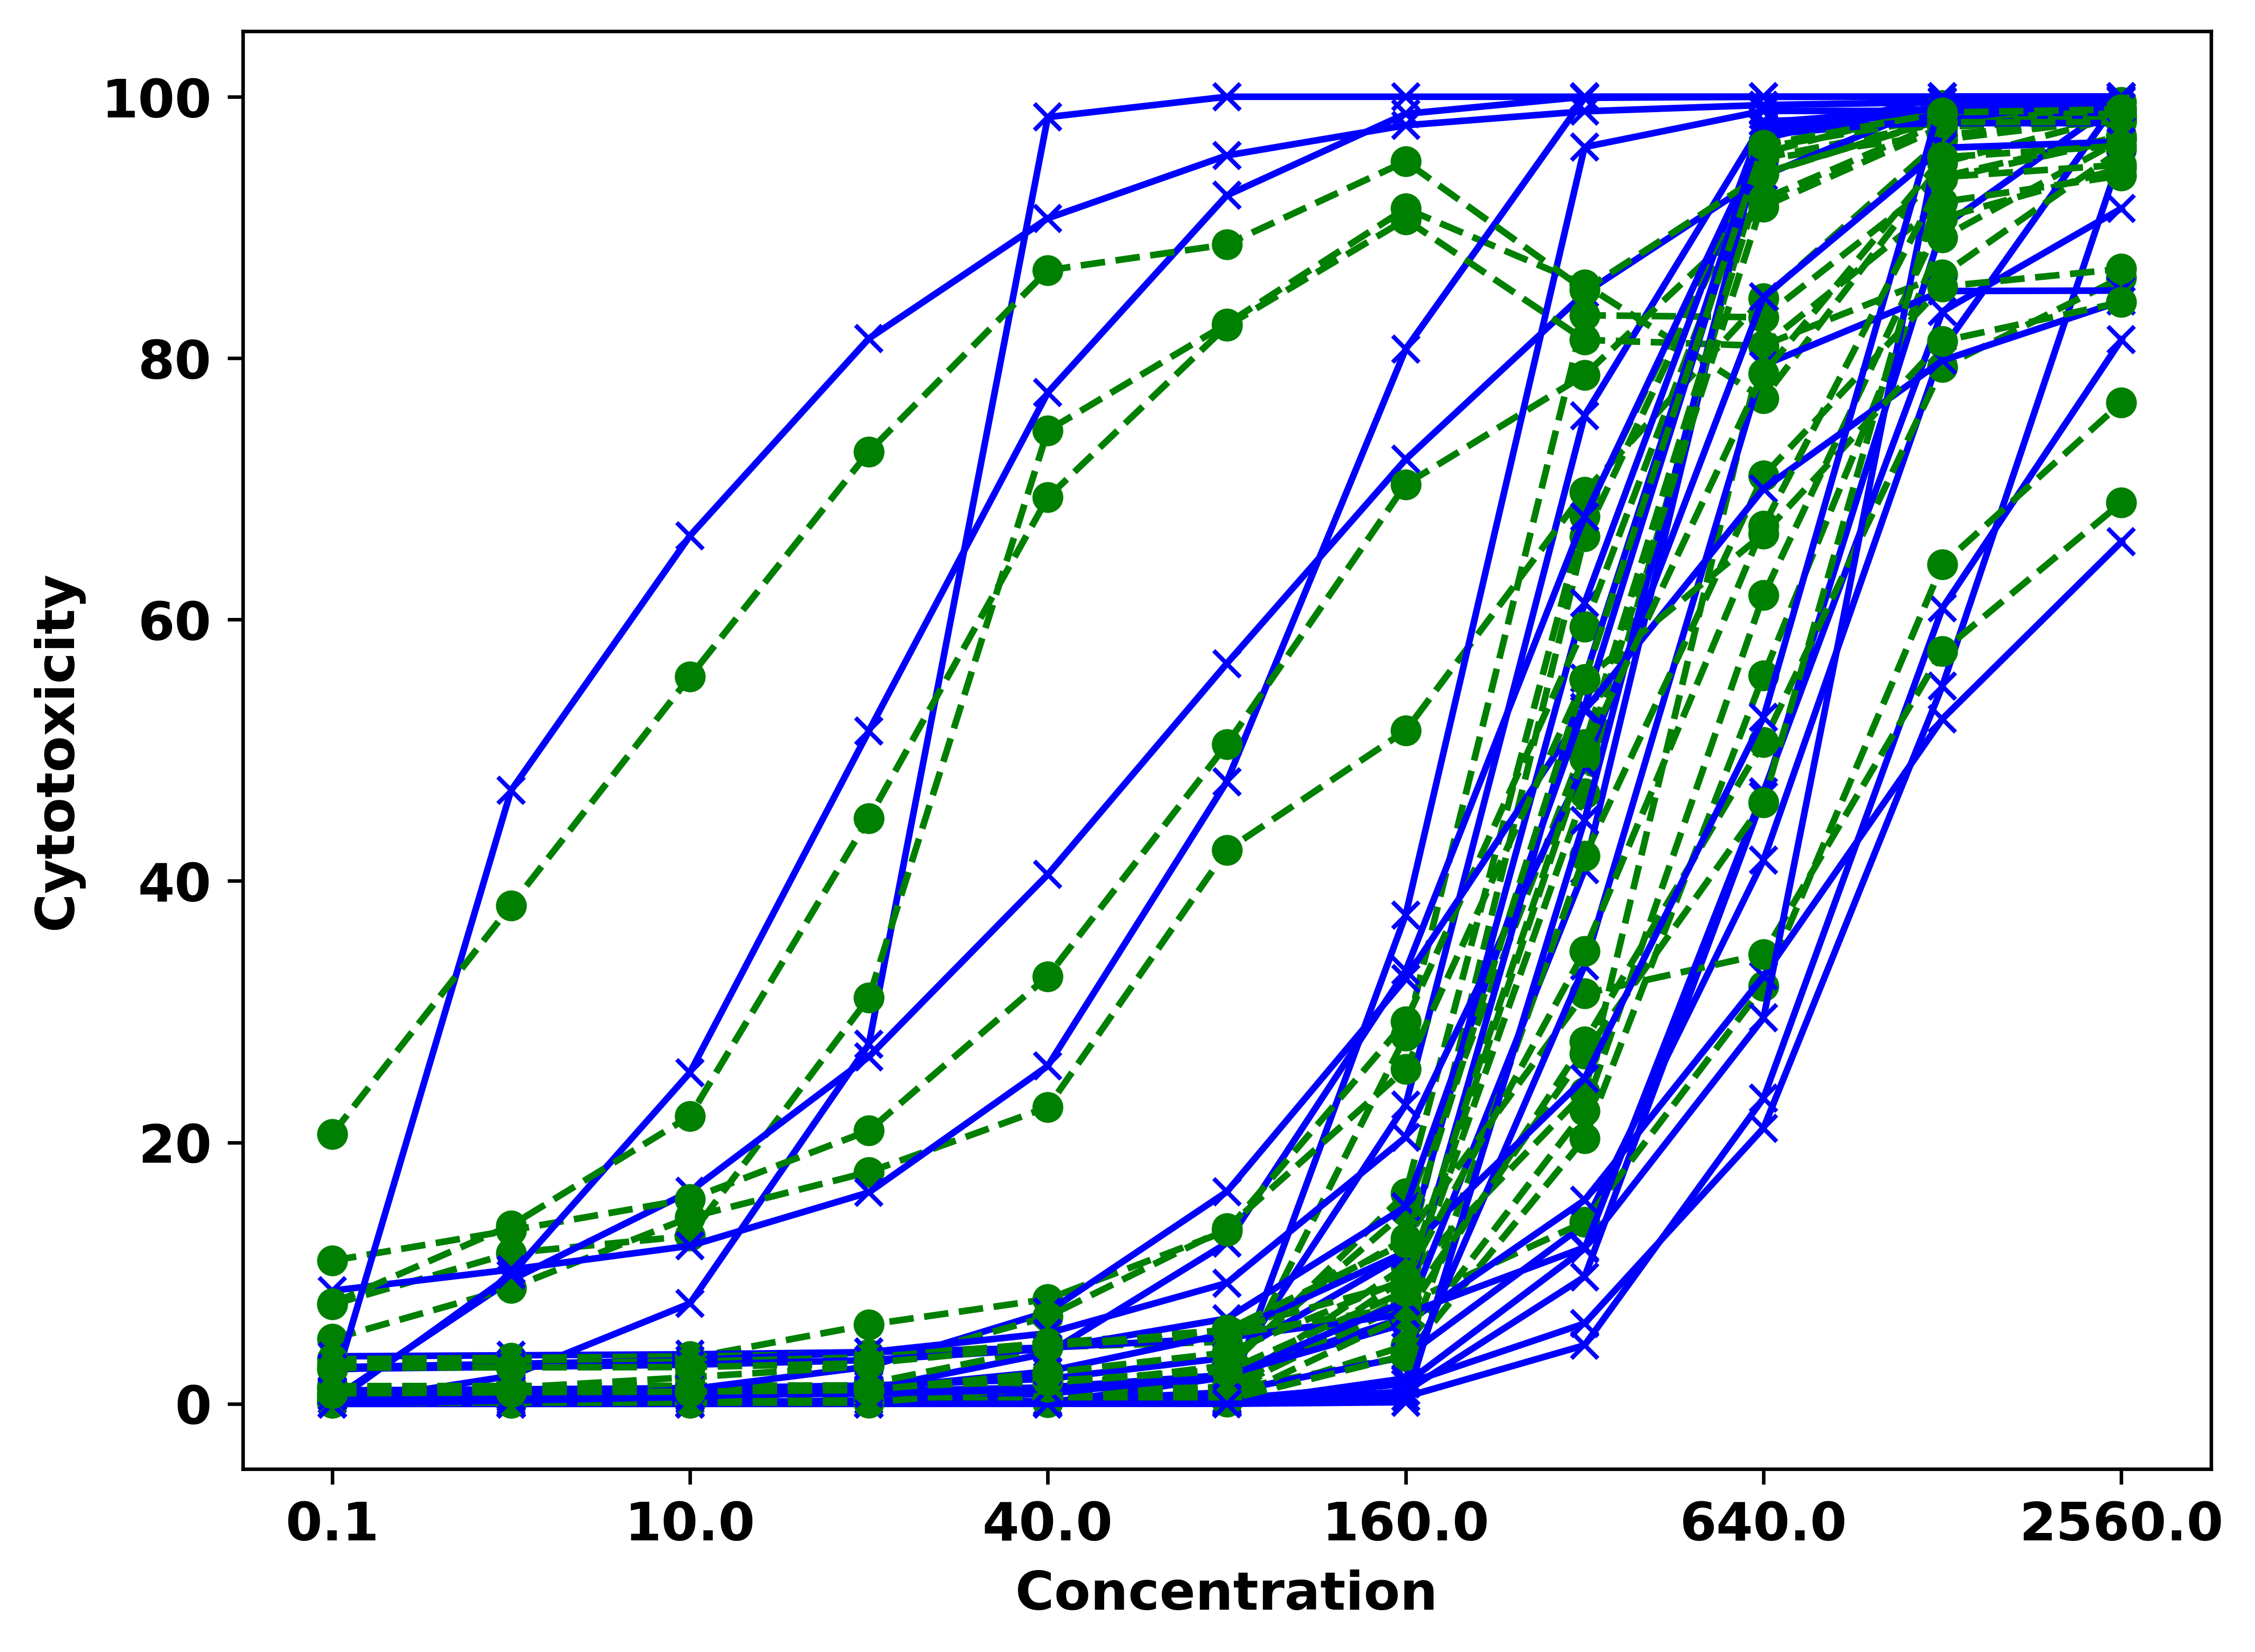

In [49]:
import matplotlib.pyplot as plt

mix_only = altogether[~altogether['Compound'].str.contains('Mix')]

#compound_name = "Mix1"

#df = testing_set[testing_set["Compound"] == compound_name]
#concentration = df["Concentration"]

# Set global font properties to bold
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Plotting
fig, ax = plt.subplots(figsize=(8,6), dpi=600)
#plt.figure(figsize=(6,5))

for compound_name in mix_only.Compound.unique():
    
    df = mix_only[mix_only["Compound"] == compound_name]
    
    plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='x', linestyle='-')
    plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='o', linestyle='--')
    
    
#plt.plot([str(i*1000000) for i in df.Concentration], df['Cytotoxicity']*100, color='blue', marker='o', linestyle='-', label='Cytotoxicity')
#plt.plot([str(i*1000000) for i in df.Concentration], df['predicted_Cytotoxicity']*100, color='green', marker='x', linestyle='--', label='Predicted Cytotoxicity')

#plt.title(compound_name)
#plt.title(compound_name)
all_xticks = [str(i*1000000) for i in df.Concentration]
plt.xticks(all_xticks[::2], all_xticks[::2], fontweight='bold')

plt.xlabel('Concentration')
plt.ylabel('Cytotoxicity')
#plt.legend()
plt.savefig("manu_figs/singles_only.png", dpi=600, bbox_inches='tight')
plt.show()

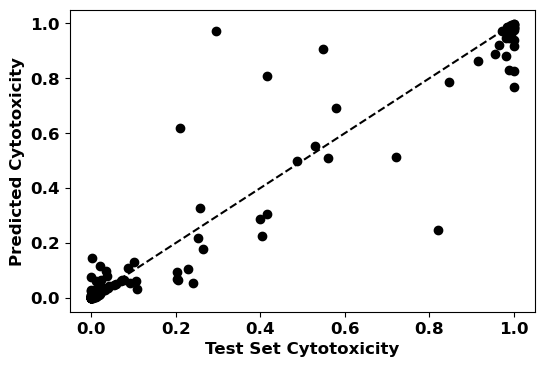

In [50]:
import matplotlib.pyplot as plt
 
# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))
 
plt.scatter(y_test,y_pred, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')
 
plt.xlabel('Test Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)
 
# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})
 
#plt.legend()
plt.savefig("ME_RF_Test_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

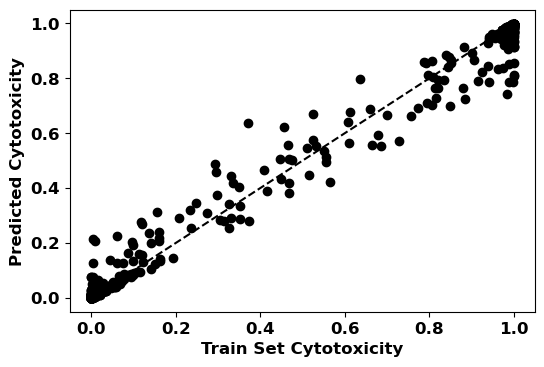

In [51]:
import matplotlib.pyplot as plt

#compound_name = "Mix5"

#df = altogether[altogether["Compound"] == compound_name]
#concentration = df["Concentration"]

# Plotting
fig, ax = plt.subplots(figsize=(6,4), dpi=100)
#plt.figure(figsize=(6,5))
plt.scatter(y_train,train_predicted, color='black', marker='o', label='Cytotoxicity')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Ideal Prediction')


plt.xlabel('Train Set Cytotoxicity',fontweight='bold', fontsize=12)
plt.ylabel('Predicted Cytotoxicity',fontweight='bold', fontsize=12)

# Make x and y-ticks bold
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.yticks(fontweight='bold')
plt.xticks(fontweight='bold')
#plt.legend(prop={'weight':'bold'})

#plt.legend()
plt.savefig("manu_figs/ME_RF_Train_Pred.png", dpi=600, bbox_inches='tight')
plt.show()

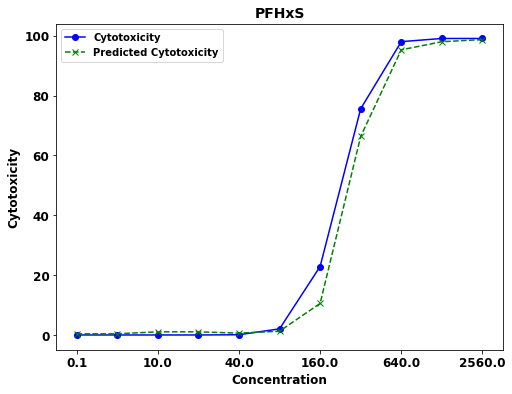

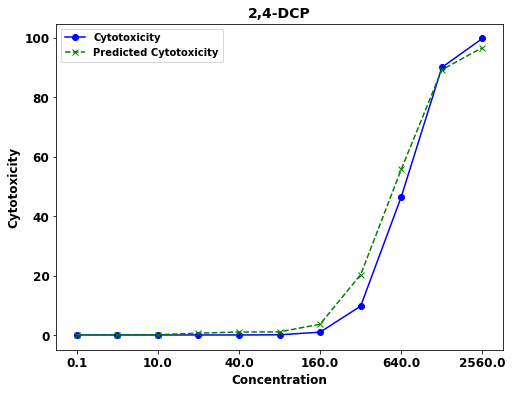

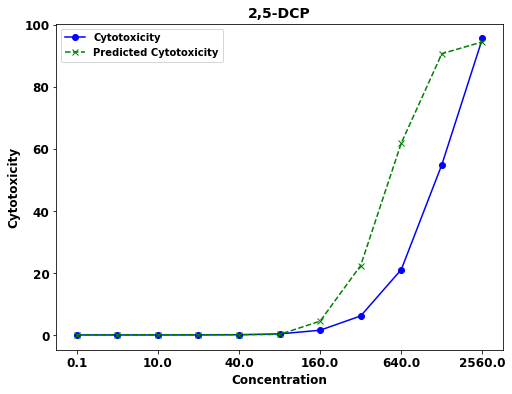

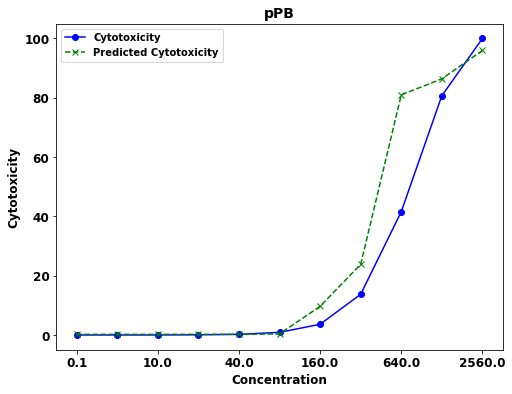

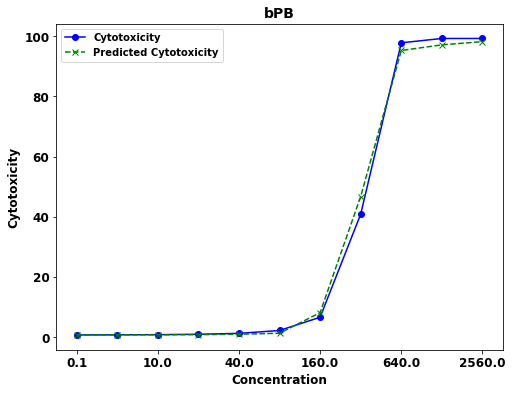

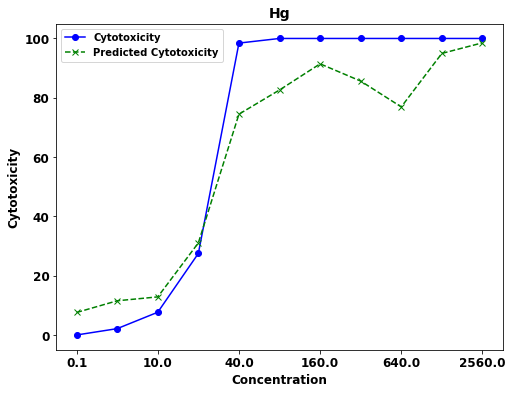

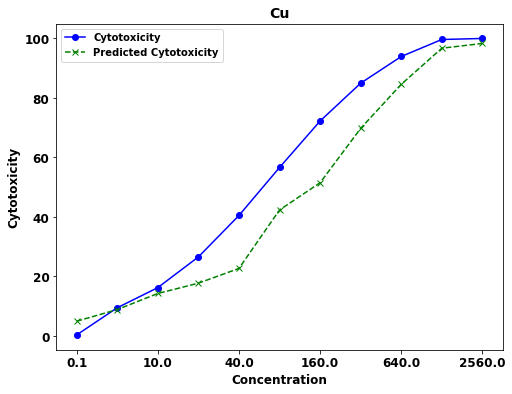

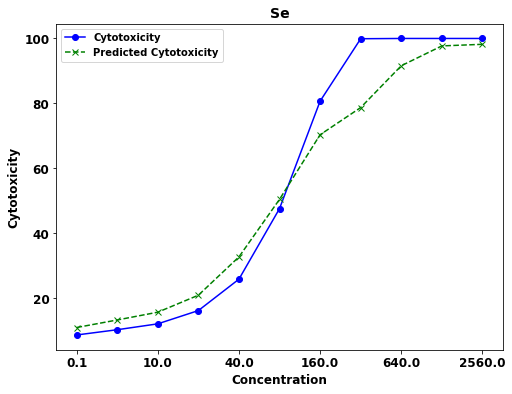

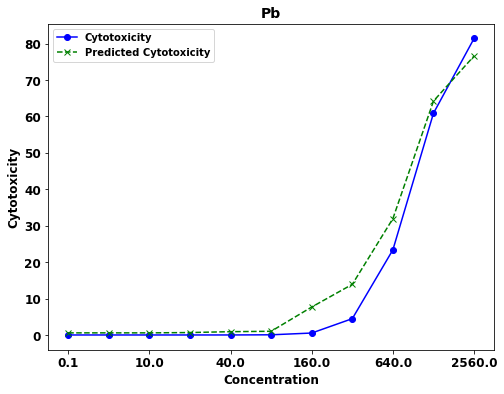

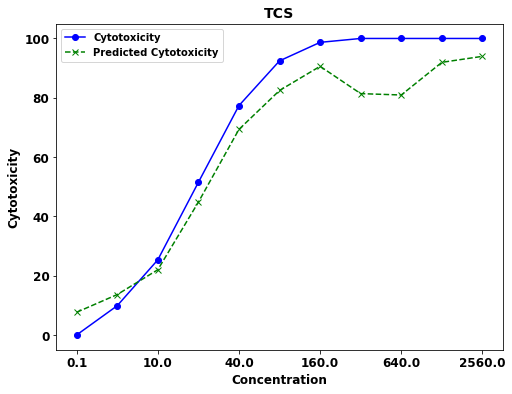

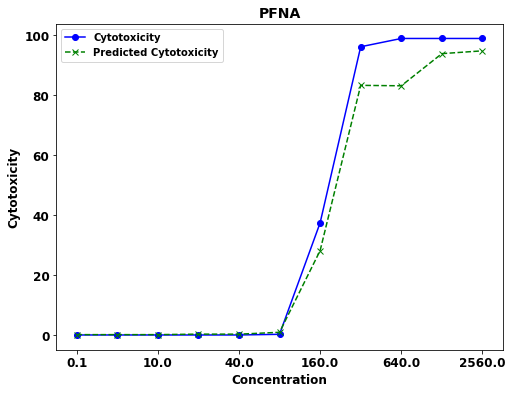

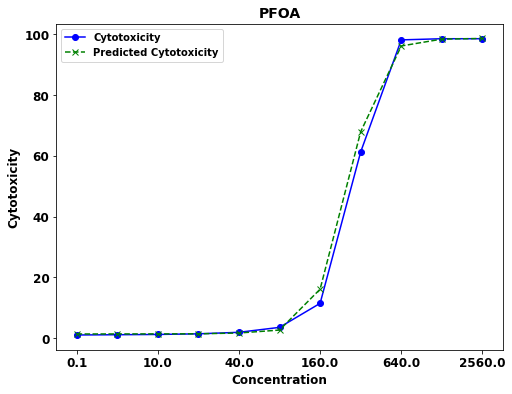

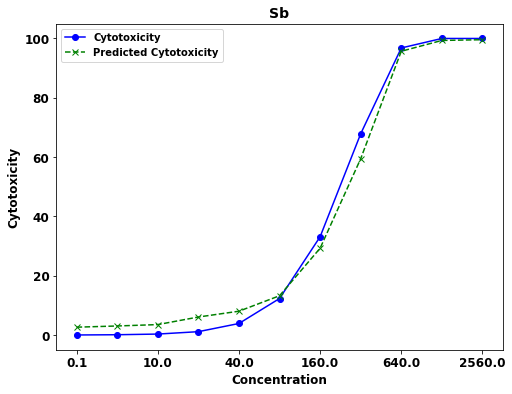

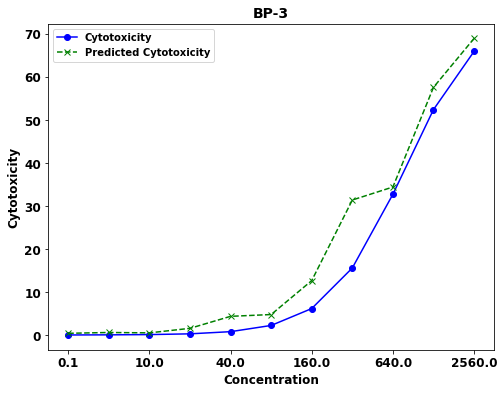

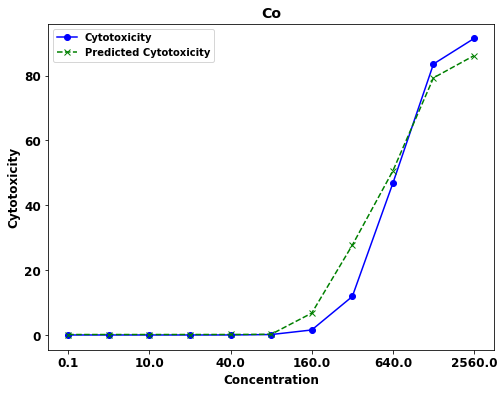

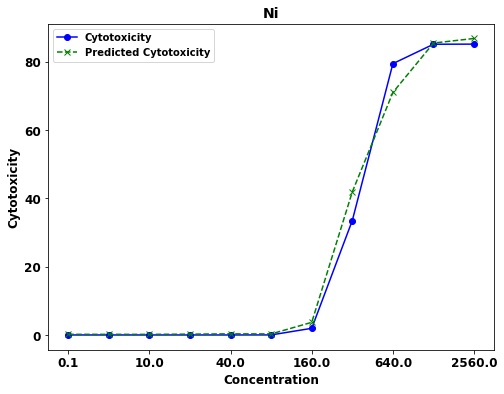

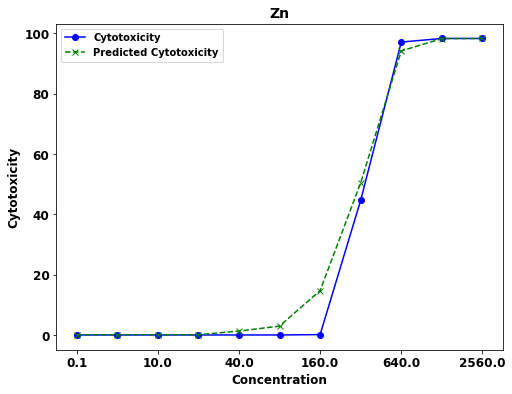

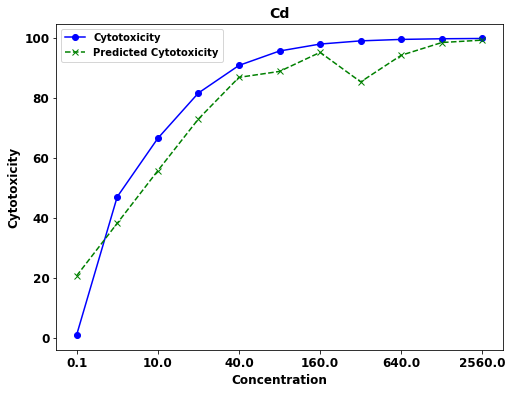

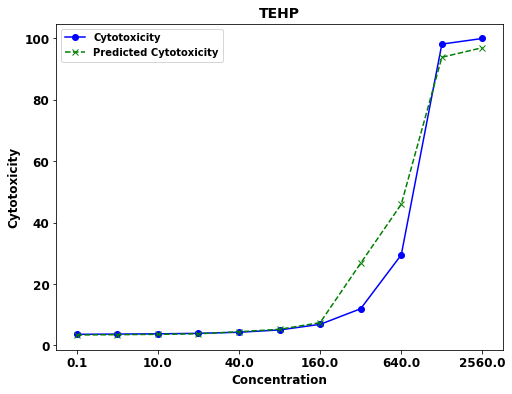

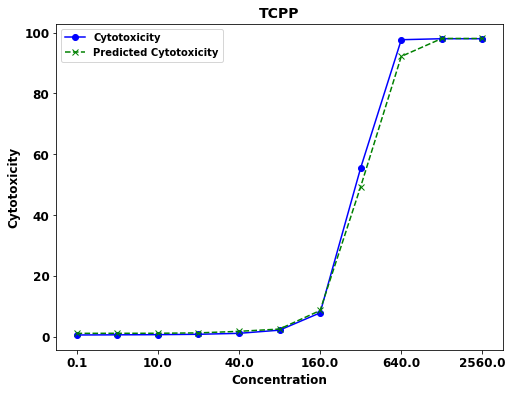

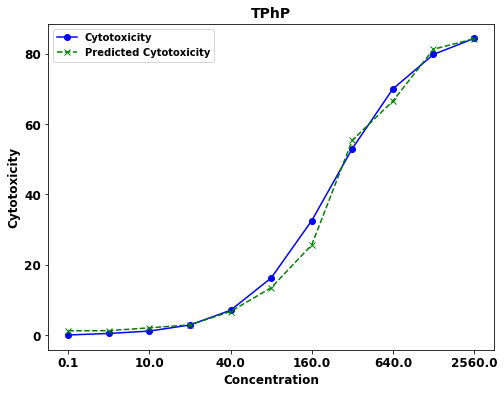

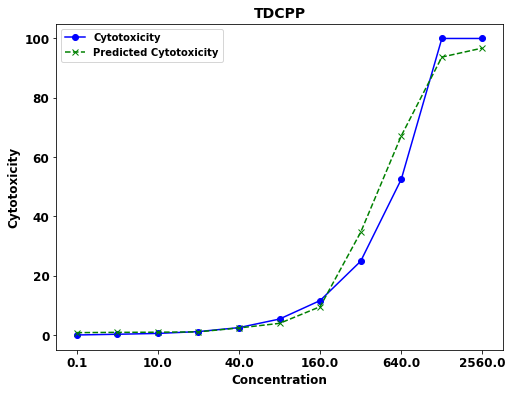

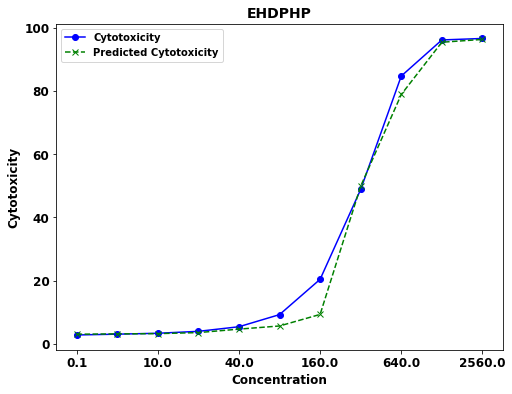

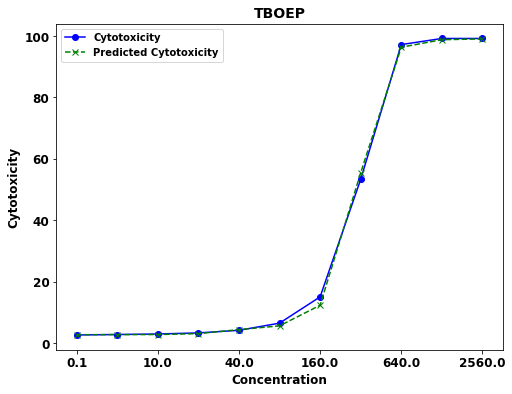

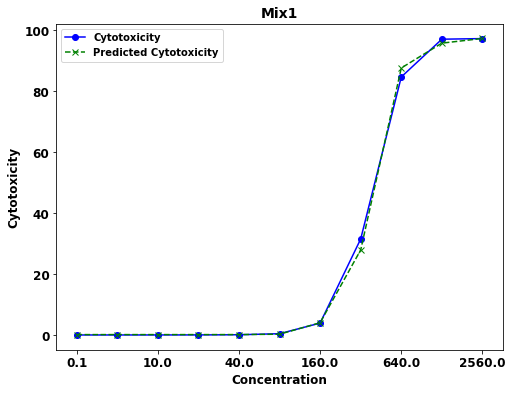

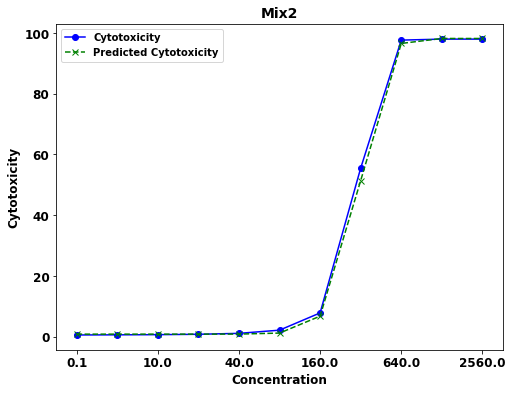

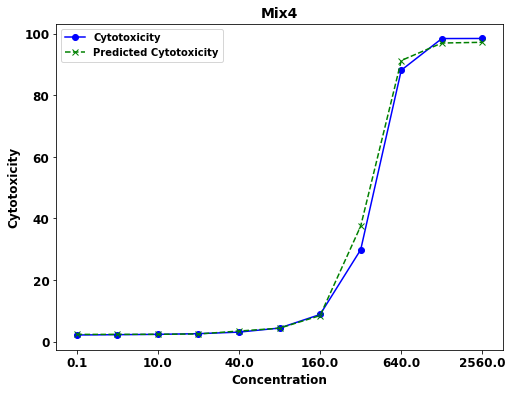

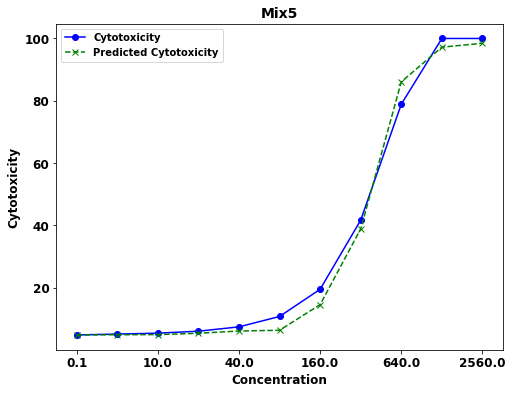

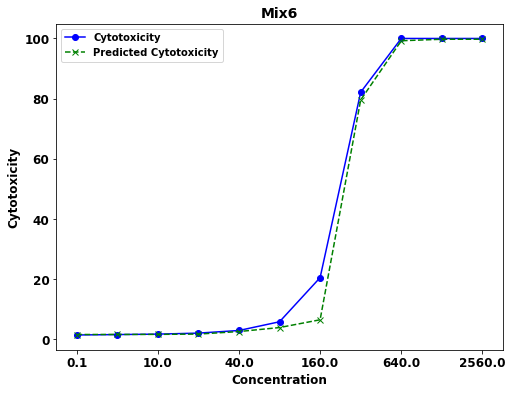

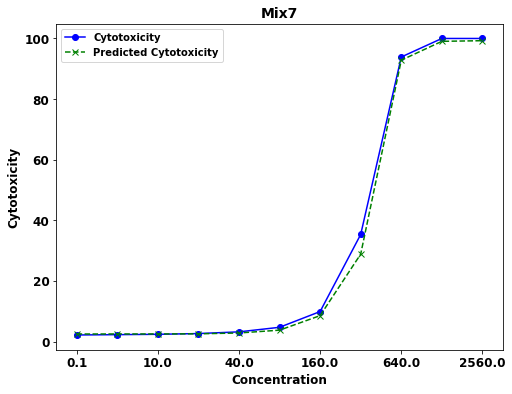

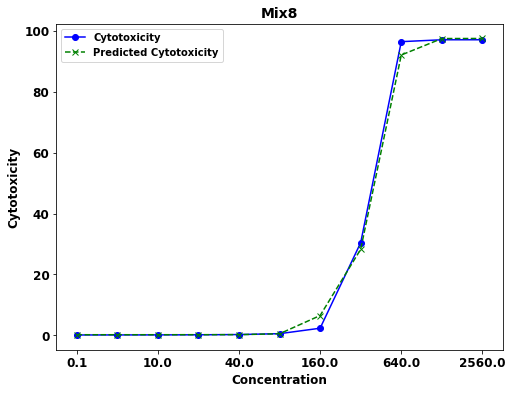

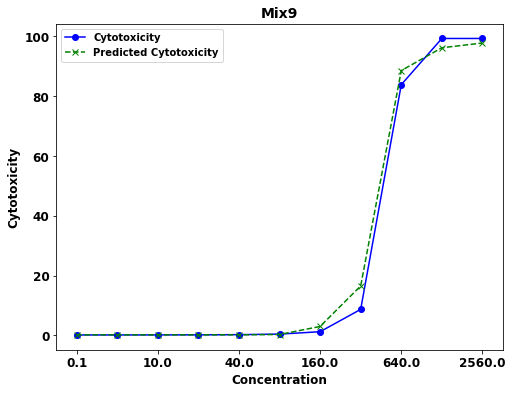

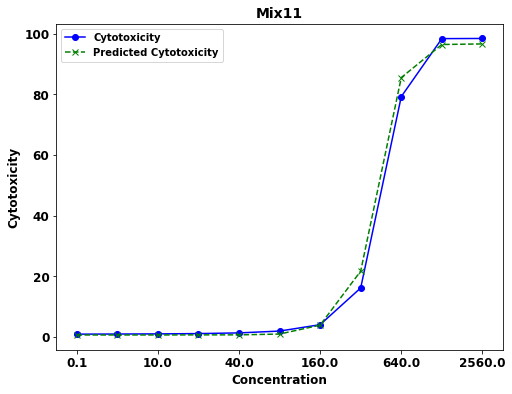

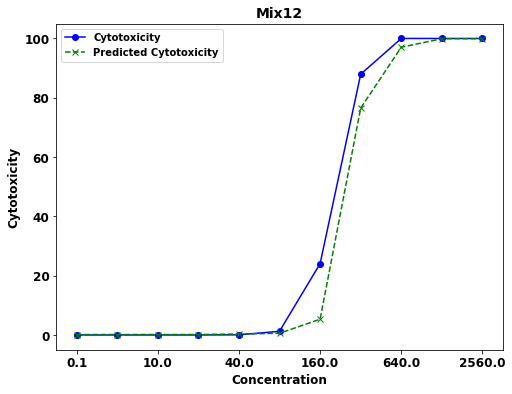

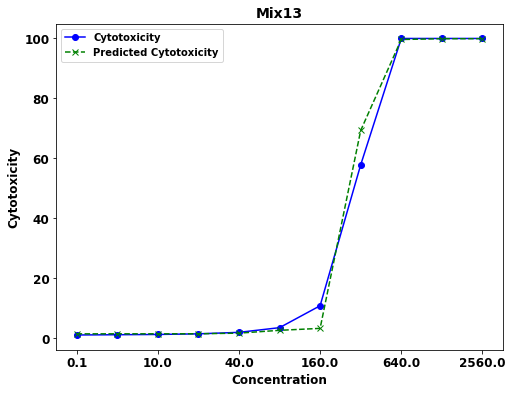

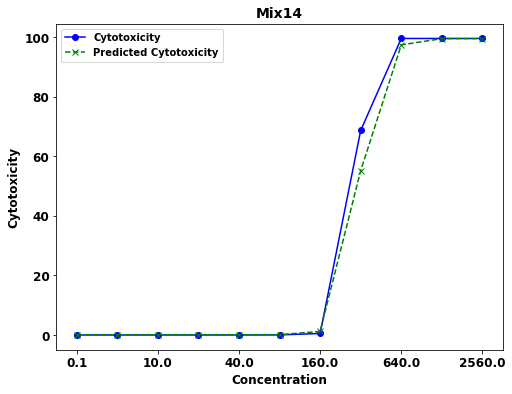

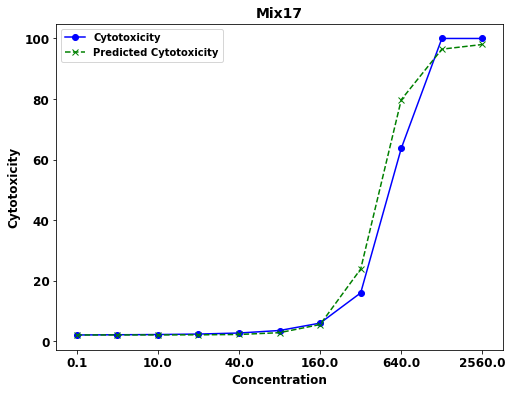

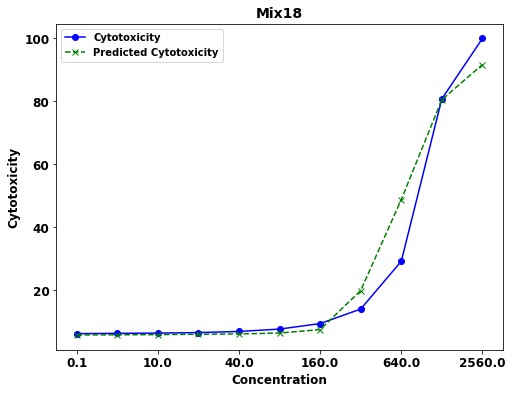

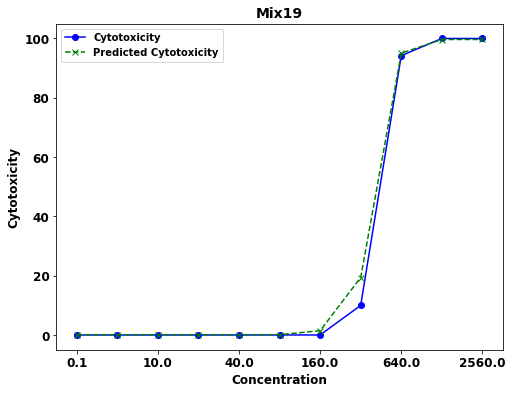

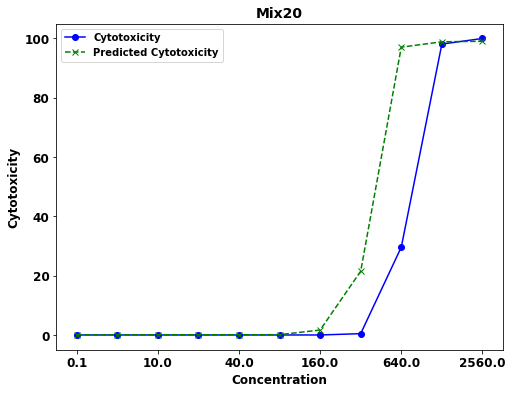

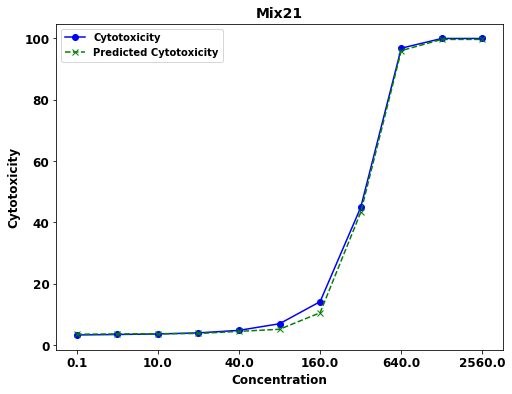

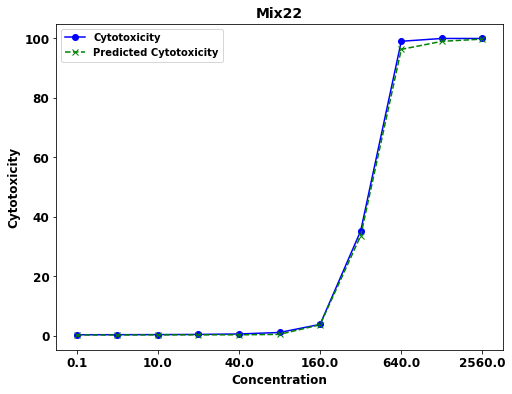

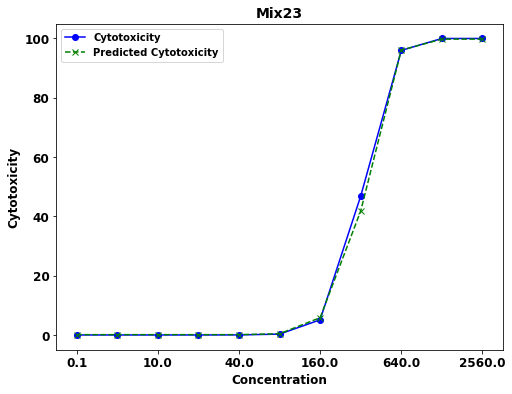

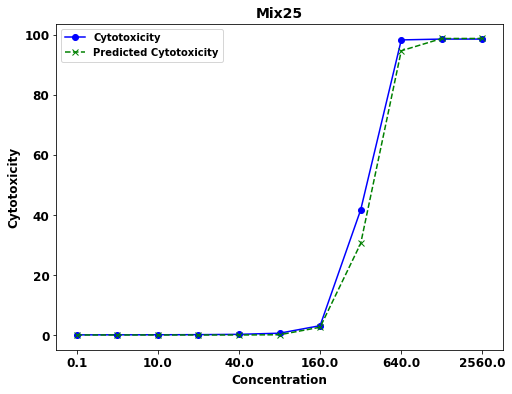

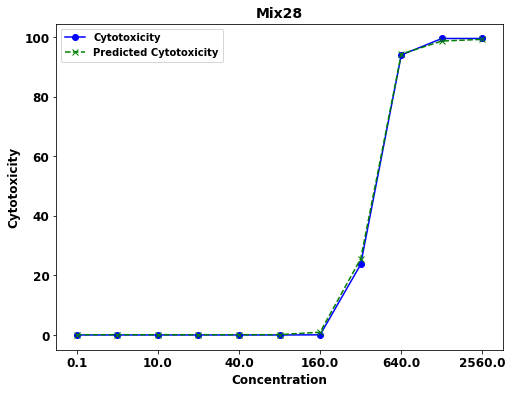

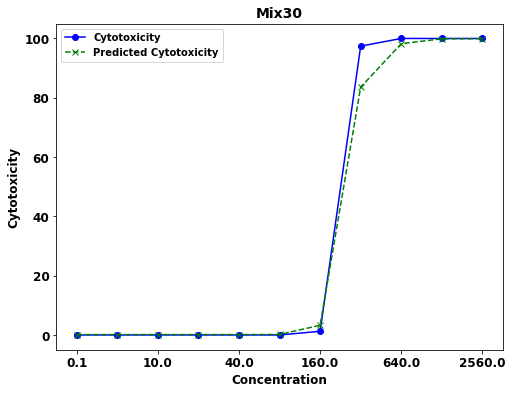

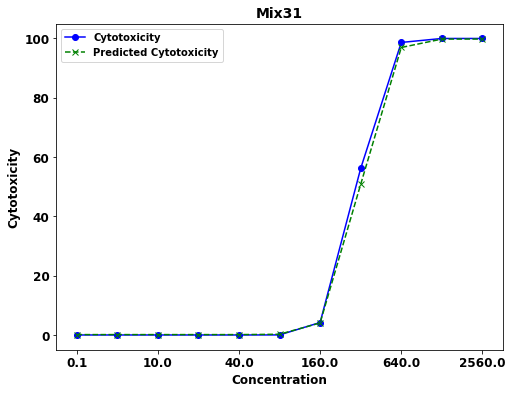

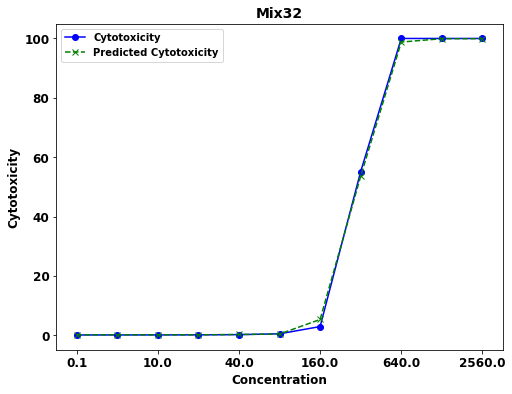

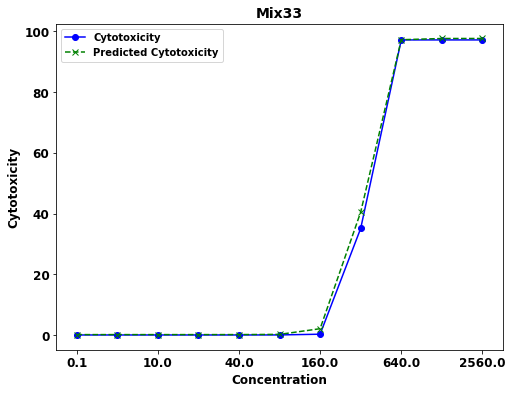

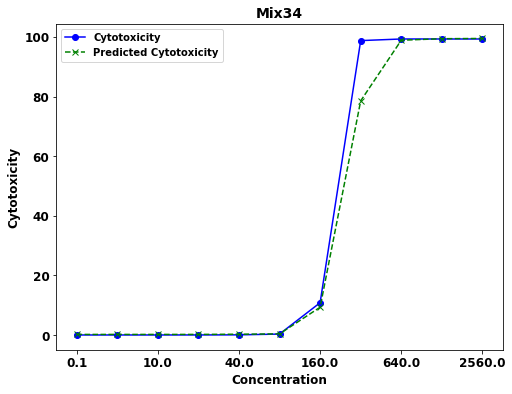

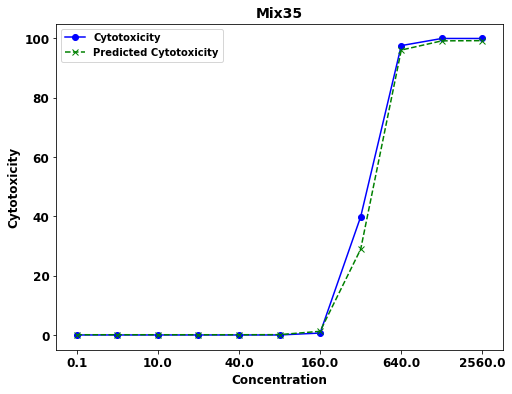

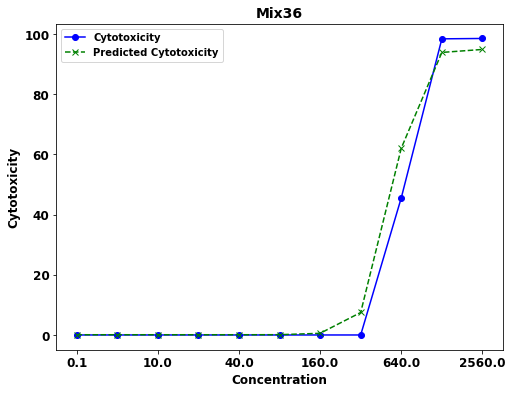

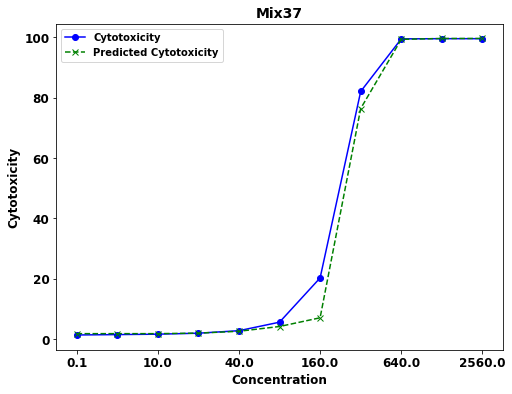

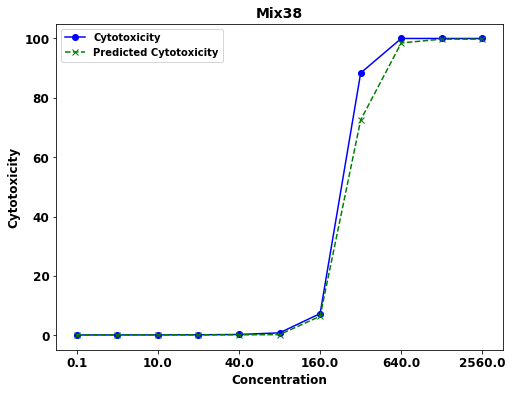

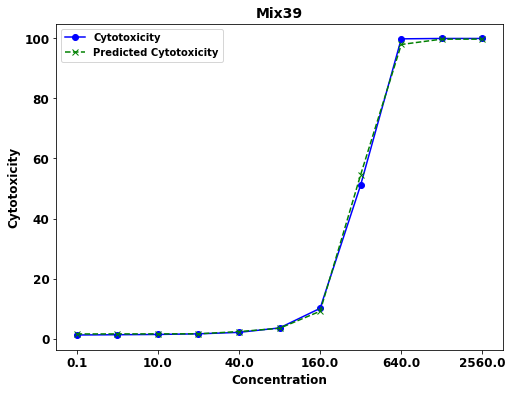

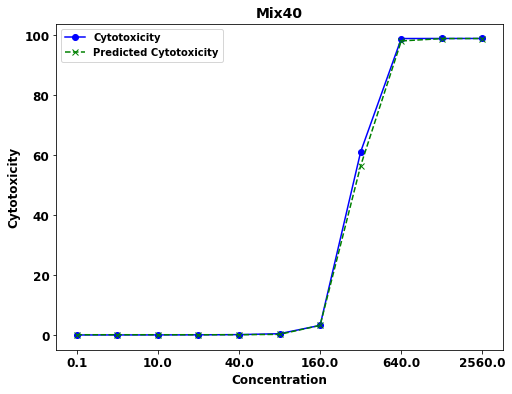

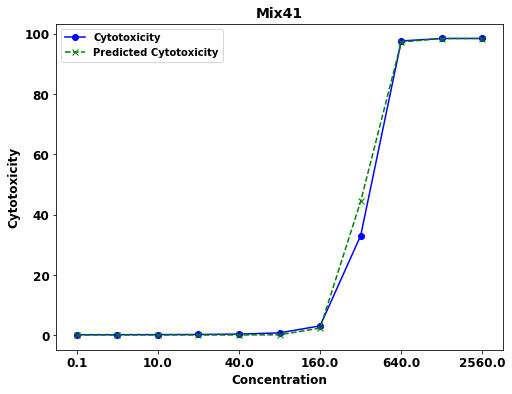

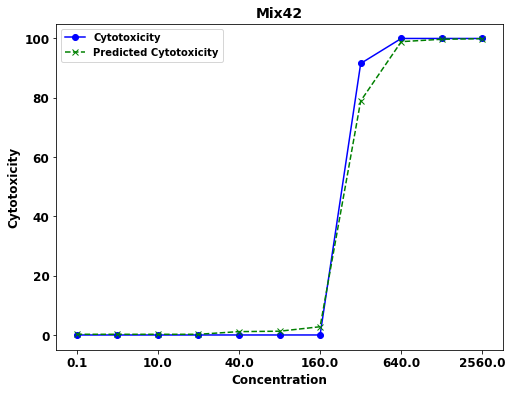

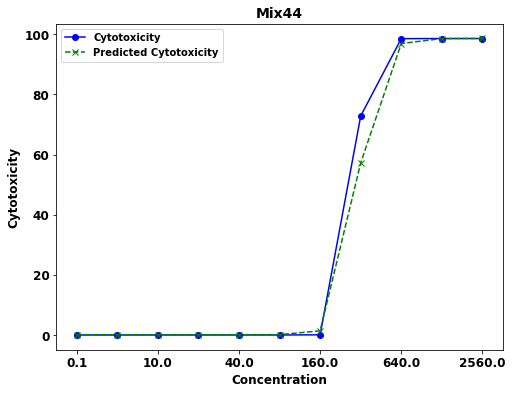

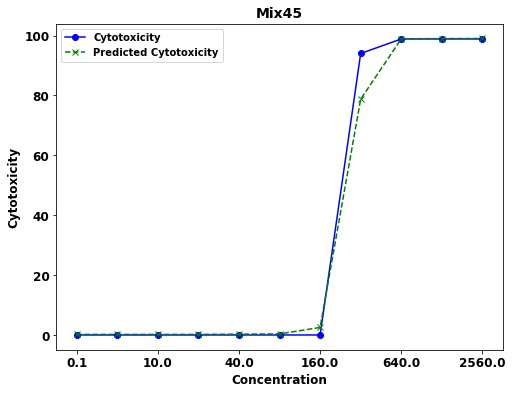

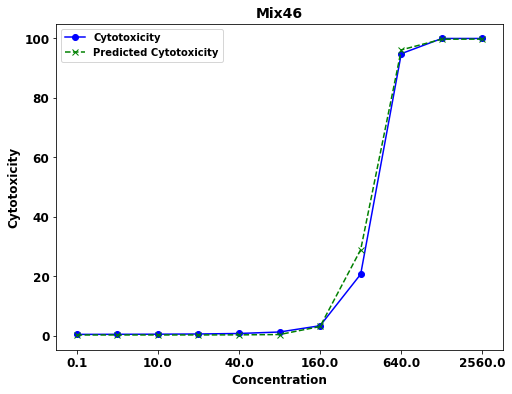

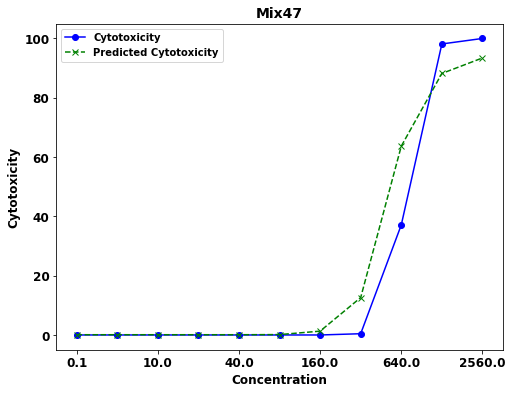

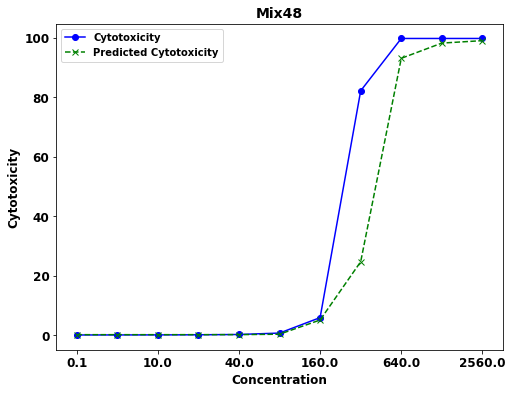

In [52]:
for i in altogether.Compound.unique():
    plot_compound(compound_name = i, dataframe = altogether)